In [ ]:
# prompt: I need to convert some Python code to R. Here's the python code:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd '/content/drive/My Drive/DiabetesML'
#      import pandas as pd
#      import numpy as np
#      file_path = '/content/drive/MyDrive/reorganized_ts.parquet' # Replace with your file path
#      df = pd.read_parquet(file_path)
#      # Identify columns that start with "source"
# columns_to_drop = [col for col in df.columns if col.startswith('source')]
# # Drop these columns from the DataFrame
# # axis=1 indicates that we are dropping columns, not rows
# # inplace=True modifies the DataFrame directly
# df.drop(columns=columns_to_drop, axis=1, inplace=True)
# # prompt: Create a code chunk that subsets the data by uuid. Give me a random subset of 200 UUIDs and overwrite the original df
# random.seed(314)
# np.random.seed(314)
# # Get a random subset of unique UUIDs
# subset_uuids = np.random.choice(df['uuid'].unique(), size=5, replace=False)
# # Get another subset that's larger for some other EDA type stuff
# subset_uuids2 = np.random.choice(df['uuid'].unique(), size=10, replace=False)
# df_full = df.copy()
# # Subset the DataFrame to include only rows with the selected UUIDs
# df_larger_sample = df[df['uuid'].isin(subset_uuids2)].copy()
# # Subset the DataFrame to include only rows with the selected UUIDs
# df = df[df['uuid'].isin(subset_uuids)].copy()

# Install required packages if not already installed
#if (!require("googledrive")) install.packages("googledrive")
#if (!require("googlesheets4")) install.packages("googlesheets4")
#googledrive::drive_auth()
if (!require("arrow")) install.packages("arrow")
if (!require("tidyverse")) install.packages("tidyverse")
if (!require("forecast")) install.packages("forecast")
if (!require("patchwork")) install.packages("patchwork")
if (!require("VIM")) install.packages("VIM")
if (!require("mice")) install.packages("mice")
if (!require('xgboost')) install.packages('xgboost')
if (!require('caret')) install.packages('caret')

print('Finished installing packages')

library(googledrive)
library(googlesheets4)
library(arrow)
library(tidyverse)
library(forecast)
library(patchwork)
library(VIM)
library(mice)
library(xgboost)
library(caret)
library(zoo)

# Authenticate and mount Google Drive
# This will open a browser window for authentication
# You might need to run this line separately and follow the prompts.



# Read in data

In [2]:

# Assuming your parquet file is in your Google Drive
# You can read the parquet file directly from the path.
# If you are working in a Colab notebook with Drive mounted, the path
# should be similar to '/content/drive/MyDrive/path/to/your/file.parquet'
file_path <- 'reorganized_ts.parquet' # Replace with your file path
data_download <- drive_get(file_path)
drive_download(data_download, overwrite = TRUE)
df <- arrow::read_parquet('reorganized_ts.parquet')
head(df)
summary(df)
# Identify columns that start with "source" and drop them
columns_to_drop <- names(df)[grep("^source", names(df))]
df <- df %>% select(-one_of(columns_to_drop))

# Set random seed for reproducibility
set.seed(123467)

# Get unique UUIDs
unique_uuids <- unique(df$uuid)

# Get a random subset of 5 unique UUIDs
subset_uuids <- sample(unique_uuids, size = 15, replace = FALSE)

# Get another random subset of 10 unique UUIDs
subset_uuids2 <- sample(unique_uuids, size = 30, replace = FALSE)

# Create a full copy of the dataframe
df_full <- df

# Subset the DataFrame to include only rows with the larger subset of UUIDs
df_larger_sample <- df %>% filter(uuid %in% subset_uuids2)

# Subset the DataFrame to include only rows with the smaller subset of UUIDs
df <- df %>% filter(uuid %in% subset_uuids)


Enter a number between 1 and 2, or enter 0 to exit.
Waiting for authentication in browser...
Press Esc/Ctrl + C to abort
Authentication complete.
v The input `path` resolved to exactly 1 file.
File downloaded:
* reorganized_ts.parquet <id: 1n5a6yE2KE6SGgL56ulpW-eVDGfmtahk1>
Saved locally as:
* ]8;;file://\\mrh.local/SP/Homes/jacob.wittman/Documents/DiabetesML/reorganized_ts.parquetreorganized_ts.parquet]8;;


# EDA

Warning message:
Removed 5611 rows containing missing values or values outside the scale range (`geom_line()`). 


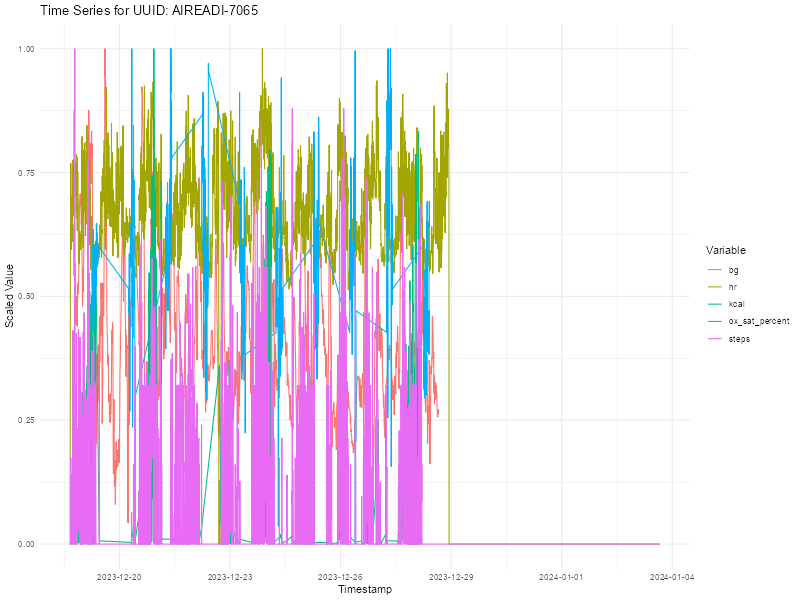

In [3]:
# Select a random UUID
random_uuid <- sample(unique(df_larger_sample$uuid), 1)
random_individual_df <- df_larger_sample %>% filter(uuid == random_uuid)

# Define columns to plot
cols_to_plot <- c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent')

# Normalize the data for plotting on a single axis
random_individual_df_scaled <- random_individual_df
for (col in cols_to_plot) {
  if (col %in% names(random_individual_df_scaled)) {
    # Check if the column contains non-NA values
    if (!all(is.na(random_individual_df_scaled[[col]]))) {
        min_val <- min(random_individual_df_scaled[[col]], na.rm = TRUE)
        max_val <- max(random_individual_df_scaled[[col]], na.rm = TRUE)
        if (max_val != min_val) { # Avoid division by zero
            random_individual_df_scaled[[paste0(col, '_scaled')]] <- (random_individual_df_scaled[[col]] - min_val) / (max_val - min_val)
        } else {
             random_individual_df_scaled[[paste0(col, '_scaled')]] <- 0.5 # Assign a mid-range value if all values are the same
        }
    } else {
        random_individual_df_scaled[[paste0(col, '_scaled')]] <- NA # Assign NA if the column is all NA
    }
  }
}

# Reshape data for plotting
library(tidyr)
df_long <- random_individual_df_scaled %>%
  select(timestamp, ends_with('_scaled')) %>%
  pivot_longer(cols = ends_with('_scaled'), names_to = "variable", values_to = "value") %>%
  mutate(variable = gsub("_scaled", "", variable))

# Plotting
library(ggplot2)
ggplot(df_long, aes(x = timestamp, y = value, color = variable)) +
  geom_line() +
  labs(title = paste("Time Series for UUID:", random_uuid),
       x = "Timestamp",
       y = "Scaled Value",
       color = "Variable") +
  scale_x_datetime(date_breaks = '3 days') +
  theme_minimal()

In [4]:
# Load required libraries
library(dplyr)
library(lubridate)

# Ensure timestamp is in datetime format
df$timestamp <- as.POSIXct(df$timestamp)

# Define measurement columns to check for duration
measurement_cols <- c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent')

# Identify individuals with more than 10 days of data for any variable
long_duration_data <- df %>%
  group_by(uuid) %>%
  summarise(
    across(all_of(measurement_cols),
           ~ if(sum(!is.na(.)) > 0) {
             as.numeric(difftime(max(timestamp[!is.na(.)]),
                               min(timestamp[!is.na(.)]),
                               units = "days"))
           } else {
             0
           },
           .names = "{.col}_duration"),
    .groups = "drop"
  ) %>%
  pivot_longer(cols = ends_with("_duration"),
               names_to = "variable",
               values_to = "duration_days") %>%
  mutate(variable = str_remove(variable, "_duration")) %>%
  filter(duration_days > 10)

cat("\nIndividuals and variables with more than 10 days of data:\n")
if(nrow(long_duration_data) > 0) {
  print(long_duration_data)

  # Get unique UUIDs that need trimming
  uuids_to_trim <- unique(long_duration_data$uuid)
  cat(sprintf("\nUnique UUIDs that need trimming: %s\n",
              paste(uuids_to_trim, collapse = ", ")))
} else {
  cat("No individuals found with more than 10 days of data for any variable.\n")
  uuids_to_trim <- character(0)
  cat(sprintf("\nUnique UUIDs that need trimming: %s\n",
              paste(uuids_to_trim, collapse = ", ")))
}

# Function to trim data for a specific uuid based on BG data window
trim_data_to_bg_window <- function(df, target_uuid) {
  individual_df <- df %>% filter(uuid == target_uuid)

  if(nrow(individual_df) == 0) {
    return(individual_df)
  }

  # Find BG data range
  bg_data <- individual_df %>% filter(!is.na(bg))

  if(nrow(bg_data) == 0) {
    cat(sprintf("Warning: No 'bg' data found for uuid %s. Cannot trim based on BG.\n",
                target_uuid))
    return(df[0, ])  # Return empty dataframe with same structure
  }

  # Get BG time window
  min_timestamp_bg <- min(bg_data$timestamp)
  max_timestamp_bg <- max(bg_data$timestamp)

  # Filter data to BG window
  trimmed_df <- individual_df %>%
    filter(timestamp >= min_timestamp_bg & timestamp <= max_timestamp_bg)

  return(trimmed_df)
}

# Create trimmed dataset
if(length(uuids_to_trim) > 0) {
  # Trim data for UUIDs that need it
  trimmed_data_list <- map(uuids_to_trim, ~ trim_data_to_bg_window(df, .x))
  trimmed_data <- bind_rows(trimmed_data_list)

  # Keep original data for UUIDs that don't need trimming
  uuids_not_to_trim <- setdiff(unique(df$uuid), uuids_to_trim)
  untrimmed_data <- df %>% filter(uuid %in% uuids_not_to_trim)

  # Combine trimmed and untrimmed data
  df_final <- bind_rows(trimmed_data, untrimmed_data)
} else {
  # No trimming needed
  df_final <- df
}

cat("\nDataFrame after trimming long duration data:\n")
if(nrow(df_final) > 0) {
  print(df_final)
} else {
  cat("No data remaining after processing and trimming.\n")
}

# Update df for subsequent use
df <- df_final


Individuals and variables with more than 10 days of data:
# A tibble: 48 x 3
   uuid         variable       duration_days
   <chr>        <chr>                  <dbl>
 1 AIREADI-1110 hr                      12.2
 2 AIREADI-1110 steps                   12.3
 3 AIREADI-1199 hr                      53.2
 4 AIREADI-1199 steps                   53.2
 5 AIREADI-1199 kcal                    12.8
 6 AIREADI-1199 ox_sat_percent          11.2
 7 AIREADI-1226 hr                      14.0
 8 AIREADI-1226 steps                   14.1
 9 AIREADI-1226 kcal                    10.8
10 AIREADI-1226 ox_sat_percent          10.2
# i 38 more rows
# i Use `print(n = ...)` to see more rows

Unique UUIDs that need trimming: AIREADI-1110, AIREADI-1199, AIREADI-1226, AIREADI-1282, AIREADI-1353, AIREADI-4205, AIREADI-4228, AIREADI-4257, AIREADI-7253, AIREADI-7272, AIREADI-7294, AIREADI-7302, AIREADI-7333, AIREADI-7402

DataFrame after trimming long duration data:
# A tibble: 40,578 x 7
   timestamp           uu


Visualizing data for individuals whose data was trimmed:


Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


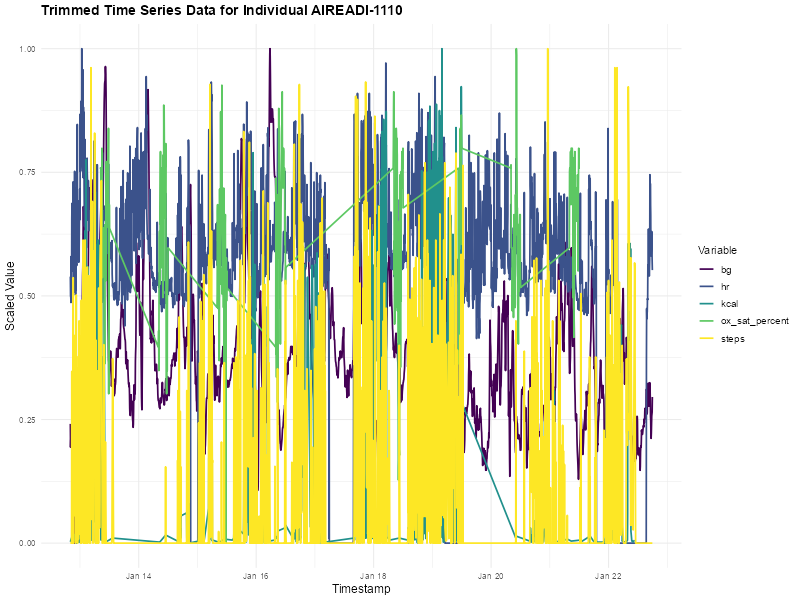

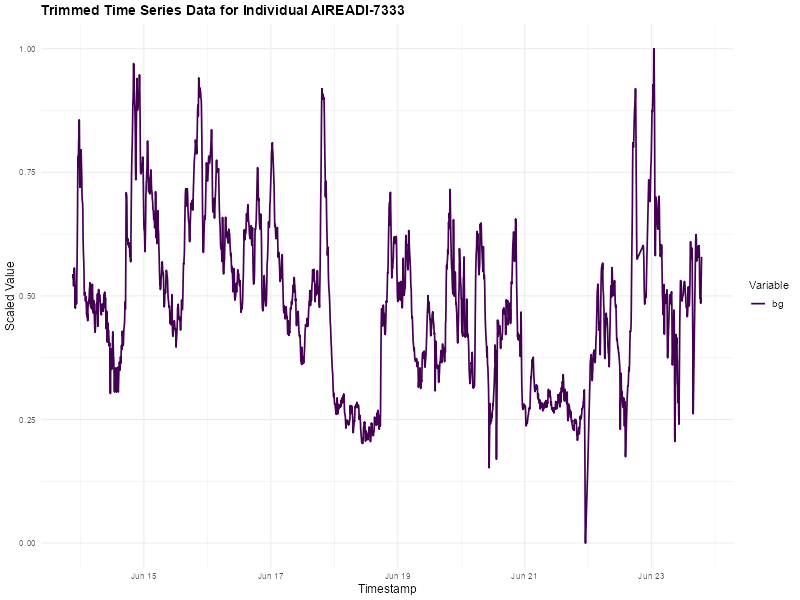

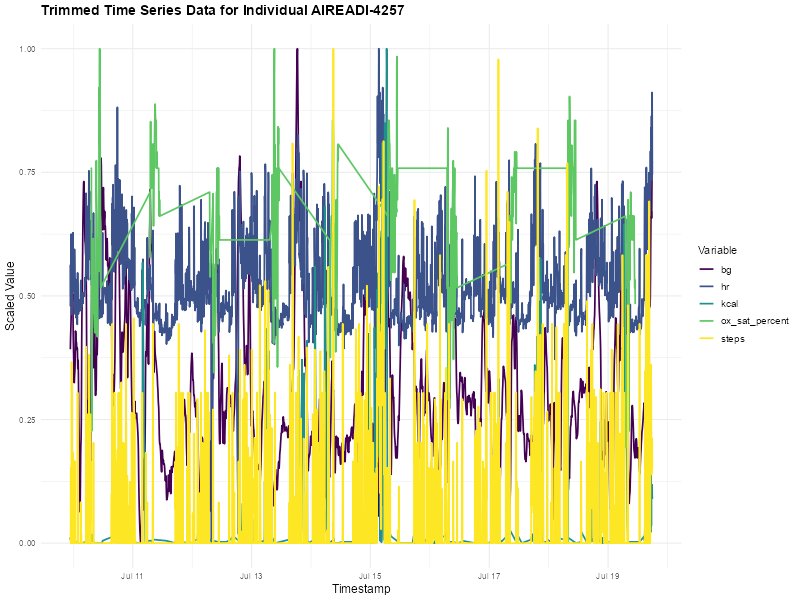

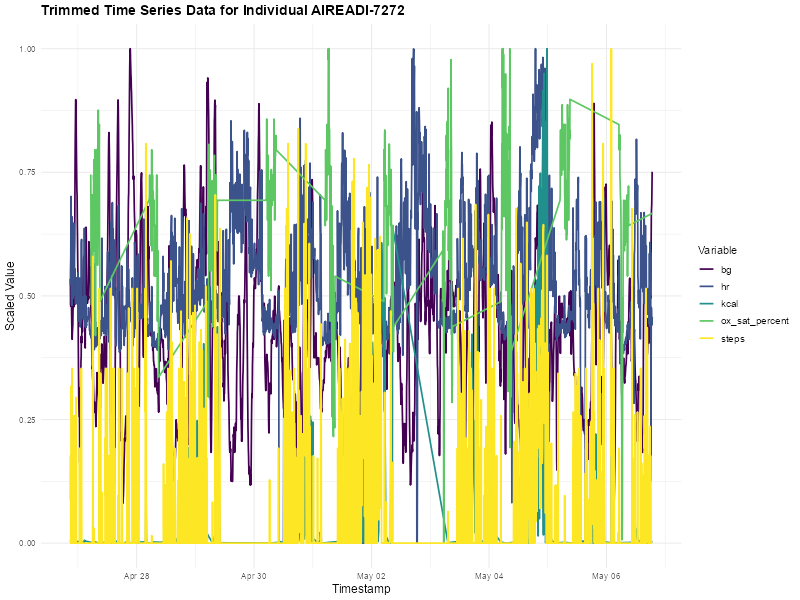

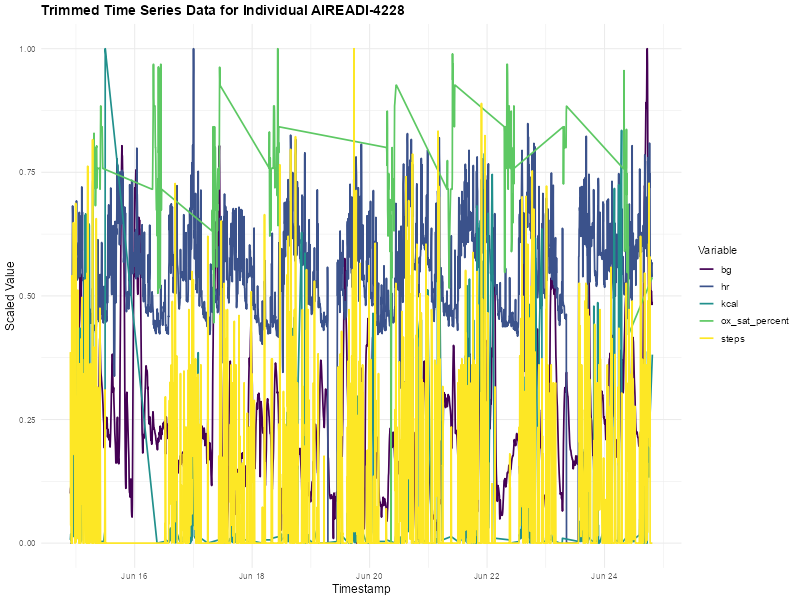

In [5]:

# Visualize the data for individuals whose data was trimmed
cat("\nVisualizing data for individuals whose data was trimmed:\n")

# Define columns to plot
cols_to_plot <- c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent')

# Select a random subset of 5 UUIDs from the ones that were trimmed
if(length(uuids_to_trim) > 0) {
  n_to_sample <- min(5, length(uuids_to_trim))
  uuids_to_visualize <- sample(uuids_to_trim, size = n_to_sample, replace = FALSE)
} else {
  uuids_to_visualize <- character(0)
  cat("No UUIDs needed trimming, skipping visualization of trimmed data.\n")
}

# Function to normalize data within groups
normalize_data <- function(x) {
  if(all(is.na(x))) {
    return(rep(NA, length(x)))
  }

  min_val <- min(x, na.rm = TRUE)
  max_val <- max(x, na.rm = TRUE)

  if(max_val == min_val) {
    return(rep(0.5, length(x)))  # Mid-range value if all values are the same
  } else {
    return((x - min_val) / (max_val - min_val))
  }
}

# Create plots for each selected UUID
plots <- map(uuids_to_visualize, function(target_uuid) {

  # Filter data for this individual
  individual_df <- df %>% filter(uuid == target_uuid)

  if(nrow(individual_df) == 0) {
    cat(sprintf("No data available for UUID %s in the trimmed DataFrame. Skipping visualization.\n",
                target_uuid))
    return(NULL)
  }

  # Check which columns exist in the data
  cols_to_melt <- intersect(cols_to_plot, names(individual_df))

  if(length(cols_to_melt) == 0) {
    cat(sprintf("No relevant measurement columns found for UUID %s in trimmed data. Skipping visualization.\n",
                target_uuid))
    return(NULL)
  }

  # Reshape data for plotting
  individual_melted <- individual_df %>%
    select(uuid, timestamp, all_of(cols_to_melt)) %>%
    pivot_longer(cols = all_of(cols_to_melt),
                 names_to = "variable",
                 values_to = "value") %>%
    filter(!is.na(value))  # Remove NA values for cleaner plotting

  if(nrow(individual_melted) == 0) {
    cat(sprintf("No non-NA data found for UUID %s after melting. Skipping plotting.\n",
                target_uuid))
    return(NULL)
  }

  # Normalize data within each variable group
  individual_melted <- individual_melted %>%
    group_by(variable) %>%
    mutate(value_scaled = normalize_data(value)) %>%
    ungroup()

  # Create the plot
  p <- ggplot(individual_melted, aes(x = timestamp, y = value_scaled, color = variable)) +
    geom_line(size = 0.8) +
    scale_color_viridis_d() +
    labs(
      title = sprintf("Trimmed Time Series Data for Individual %s", target_uuid),
      x = "Timestamp",
      y = "Scaled Value",
      color = "Variable"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(size = 14, face = "bold"),
      axis.title = element_text(size = 12),
      legend.title = element_text(size = 11),
      legend.text = element_text(size = 10)
    )

  return(p)
})

# Remove NULL plots and display the remaining ones
plots <- compact(plots)

if(length(plots) > 0) {
  # Display plots
  walk(plots, print)
} else {
  cat("No plots could be generated for the selected UUIDs.\n")
}

## ACF/PACF

ACF/PACF Analysis Summary
Dataset shape: 40578 rows x 7 columns
Number of individuals: 15
Variables to analyze: bg, hr, steps, kcal, ox_sat_percent
Minimum observations per individual: 50

bg:
  - Total non-null observations: 40542
  - Overall mean: 135.5876
  - Overall std: 40.0865
  - Valid individuals: 15
  - Average observations per valid individual: 2702.8
  - Range of observations per individual: 1085 - 2855
  - Range of individual std deviations: 14.7601 - 46.5390

hr:
  - Total non-null observations: 33407
  - Overall mean: 73.4871
  - Overall std: 19.8490
  - Valid individuals: 13
  - Average observations per valid individual: 2569.8
  - Range of observations per individual: 1085 - 2855
  - Range of individual std deviations: 12.3720 - 29.6673

steps:
  - Total non-null observations: 33410
  - Overall mean: 18.4800
  - Overall std: 32.4861
  - Valid individuals: 13
  - Average observations per valid individual: 2570.0
  - Range of observations per individual: 1085 - 2855
  - R

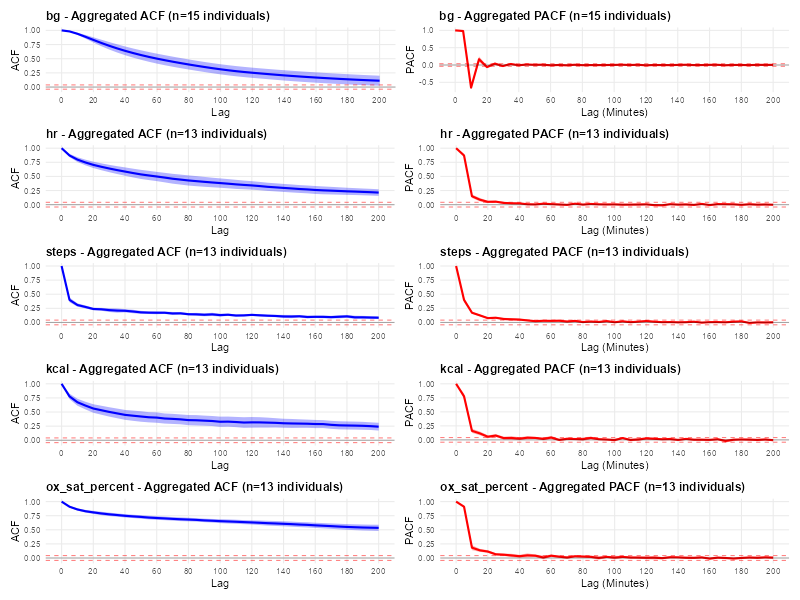

$title
[1] "Aggregated ACF and PACF Analysis - All Individuals"

$subtitle

$caption
list()
attr(,"class")
[1] "waiver"

$tag_levels
list()
attr(,"class")
[1] "waiver"

$tag_prefix
list()
attr(,"class")
[1] "waiver"

$tag_suffix
list()
attr(,"class")
[1] "waiver"

$tag_sep
list()
attr(,"class")
[1] "waiver"

$theme
List of 1
 $ plot.title:List of 11
  ..$ family       : NULL
  ..$ face         : NULL
  ..$ colour       : NULL
  ..$ size         : num 16
  ..$ hjust        : num 0.5
  ..$ vjust        : NULL
  ..$ angle        : NULL
  ..$ lineheight   : NULL
  ..$ margin       : NULL
  ..$ debug        : NULL
  ..$ inherit.blank: logi FALSE
  ..- attr(*, "class")= chr [1:2] "element_text" "element"
 - attr(*, "class")= chr [1:2] "theme" "gg"
 - attr(*, "complete")= logi FALSE
 - attr(*, "validate")= logi TRUE

attr(,"class")
[1] "plot_annotation"

In [6]:
# Load required libraries
library(dplyr)
library(ggplot2)
library(tidyr)
library(purrr)
library(forecast)
library(patchwork)

# Function to preprocess time series data
preprocess_series <- function(data, min_obs = 50) {
  # Remove NA values
  clean_data <- data[!is.na(data)]

  # Check minimum length
  if(length(clean_data) < min_obs) {
    return(NULL)
  }

  # Check for constant values (no variation)
  if(length(unique(clean_data)) <= 1) {
    cat(sprintf("Warning: Series has constant values (sd = %.6f)\n", sd(clean_data)))
    return(NULL)
  }

  # Check for extremely low variation
  if(sd(clean_data) < 1e-10) {
    cat(sprintf("Warning: Series has very low variation (sd = %.6f)\n", sd(clean_data)))
    return(NULL)
  }

  return(clean_data)
}

# Function to safely calculate ACF and PACF
safe_acf_pacf <- function(data, max_lags = 40) {
  tryCatch({
    # Adjust max_lags if data is too short
    effective_lags <- min(max_lags, length(data) - 1, length(data) %/% 4)

    if(effective_lags < 1) {
      return(list(acf = NULL, pacf = NULL))
    }

    # Calculate ACF
    acf_result <- tryCatch({
      acf(data, lag.max = effective_lags, plot = FALSE, na.action = na.pass)
    }, error = function(e) {
      cat("Warning: ACF calculation failed\n")
      return(NULL)
    })

    # Calculate PACF
    pacf_result <- tryCatch({
      pacf(data, lag.max = effective_lags, plot = FALSE, na.action = na.pass)
    }, error = function(e) {
      cat("Warning: PACF calculation failed, using zeros\n")
      return(list(acf = rep(0, effective_lags)))
    })

    acf_vals <- if(!is.null(acf_result)) acf_result$acf[,,1] else NULL
    pacf_vals <- if(!is.null(pacf_result)) c(1, pacf_result$acf[,,1]) else NULL

    return(list(acf = acf_vals, pacf = pacf_vals))

  }, error = function(e) {
    cat(sprintf("Error in ACF/PACF calculation: %s\n", e$message))
    return(list(acf = NULL, pacf = NULL))
  })
}

# Function to plot aggregated ACF and PACF
plot_aggregated_acf_pacf <- function(df, uuid_col = 'uuid',
                                    variables = c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent'),
                                    lag_interval = 5,
                                    max_lags = 40, min_obs_per_individual = 50) {

  cat("Processing ACF/PACF analysis for all variables...\n")

  # Process each variable
  plot_list <- map(variables, function(var) {
    cat(sprintf("\nProcessing variable: %s\n", var))

    if(!var %in% names(df)) {
      cat(sprintf("Warning: Variable '%s' not found in dataframe\n", var))

      # Create empty plots with warning message
      empty_plot <- ggplot() +
        annotate("text", x = 0.5, y = 0.5, label = sprintf("Variable %s not found", var)) +
        theme_void()

      return(list(acf_plot = empty_plot, pacf_plot = empty_plot))
    }

    acf_values <- list()
    pacf_values <- list()
    valid_individuals <- 0
    skipped_individuals <- 0

    # Process each individual
    unique_uuids <- unique(df[[uuid_col]])

    for(uuid in unique_uuids) {
      individual_data <- df[df[[uuid_col]] == uuid, var]

      # Preprocess data
      clean_data <- preprocess_series(individual_data, min_obs = min_obs_per_individual)

      if(is.null(clean_data)) {
        skipped_individuals <- skipped_individuals + 1
        next
      }

      # Calculate ACF/PACF
      result <- safe_acf_pacf(clean_data, max_lags)

      if(!is.null(result$acf) && !is.null(result$pacf)) {
        acf_values[[length(acf_values) + 1]] <- result$acf
        pacf_values[[length(pacf_values) + 1]] <- result$pacf
        valid_individuals <- valid_individuals + 1
      } else {
        skipped_individuals <- skipped_individuals + 1
      }
    }

    cat(sprintf("  Valid individuals: %d\n", valid_individuals))
    cat(sprintf("  Skipped individuals: %d\n", skipped_individuals))

    if(length(acf_values) > 0) {
      # Find minimum length to align all series
      min_len <- min(sapply(acf_values, length))
      acf_values <- map(acf_values, ~ .x[1:min_len])
      pacf_values <- map(pacf_values, ~ .x[1:min_len])

      # Convert to matrices and calculate statistics
      acf_matrix <- do.call(rbind, acf_values)
      pacf_matrix <- do.call(rbind, pacf_values)

      acf_mean <- colMeans(acf_matrix, na.rm = TRUE)
      acf_sd <- apply(acf_matrix, 2, sd, na.rm = TRUE)
      pacf_mean <- colMeans(pacf_matrix, na.rm = TRUE)
      pacf_sd <- apply(pacf_matrix, 2, sd, na.rm = TRUE)

      # Standard error for confidence intervals
      acf_se <- acf_sd / sqrt(nrow(acf_matrix))
      pacf_se <- pacf_sd / sqrt(nrow(pacf_matrix))

      lags <- 0:(length(acf_mean) - 1) * lag_interval

      # Estimate significance bound
      avg_n <- mean(sapply(unique_uuids, function(uuid) {
        individual_data <- df[df[[uuid_col]] == uuid, var]
        clean_data <- individual_data[!is.na(individual_data)]
        if(length(clean_data) >= min_obs_per_individual) length(clean_data) else 0
      }))
      avg_n <- avg_n[avg_n > 0]
      sig_bound <- ifelse(length(avg_n) > 0, 1.96 / sqrt(mean(avg_n)), 0.1)

      # Create data frames for plotting
      acf_df <- data.frame(
        lag = lags,
        mean = acf_mean,
        lower = acf_mean - 1.96 * acf_se,
        upper = acf_mean + 1.96 * acf_se
      )

      pacf_df <- data.frame(
        lag = lags,
        mean = pacf_mean,
        lower = pacf_mean - 1.96 * pacf_se,
        upper = pacf_mean + 1.96 * pacf_se
      )

      # Create ACF plot
      acf_plot <- ggplot(acf_df, aes(x = lag)) +
        geom_line(aes(y = mean), color = "blue", size = 1) +
        geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.3, fill = "blue") +
        geom_hline(yintercept = 0, color = "black", alpha = 0.3) +
        geom_hline(yintercept = c(sig_bound, -sig_bound),
                   color = "red", linetype = "dashed", alpha = 0.5) +
        labs(
          title = sprintf("%s - Aggregated ACF (n=%d individuals)", var, valid_individuals),
          x = "Lag",
          y = "ACF"
        ) +
        theme_minimal() +
        theme(
          plot.title = element_text(size = 12, face = "bold"),
          panel.grid.minor = element_blank()
        ) +
        scale_x_continuous(breaks = function(x) pretty(x, n = 10))

      # Create PACF plot
      pacf_plot <- ggplot(pacf_df, aes(x = lag)) +
        geom_line(aes(y = mean), color = "red", size = 1) +
        geom_ribbon(aes(ymin = lower, ymax = upper), alpha = 0.3, fill = "red") +
        geom_hline(yintercept = 0, color = "black", alpha = 0.3) +
        geom_hline(yintercept = c(sig_bound, -sig_bound),
                   color = "red", linetype = "dashed", alpha = 0.5) +
        labs(
          title = sprintf("%s - Aggregated PACF (n=%d individuals)", var, valid_individuals),
          x = "Lag (Minutes)",
          y = "PACF"
        ) +
        theme_minimal() +
        theme(
          plot.title = element_text(size = 12, face = "bold"),
          panel.grid.minor = element_blank()
        ) +
        scale_x_continuous(breaks = function(x) pretty(x, n = 10))

    } else {
      # Create empty plots with warning message
      warning_text <- sprintf("No valid data for %s\n(%d individuals skipped)",
                             var, skipped_individuals)

      acf_plot <- ggplot() +
        annotate("text", x = 0.5, y = 0.5, label = warning_text, hjust = 0.5) +
        labs(title = sprintf("%s - Aggregated ACF", var)) +
        theme_minimal()

      pacf_plot <- ggplot() +
        annotate("text", x = 0.5, y = 0.5, label = warning_text, hjust = 0.5) +
        labs(title = sprintf("%s - Aggregated PACF", var)) +
        theme_minimal()
    }

    return(list(acf_plot = acf_plot, pacf_plot = pacf_plot))
  })

  # Combine plots using patchwork
  combined_plot <- plot_list %>%
    map(~ .x$acf_plot | .x$pacf_plot) %>%  # Combine ACF and PACF side by side for each variable
    reduce(`/`) %>%  # Stack variables vertically
    plot_annotation(
      title = "Aggregated ACF and PACF Analysis - All Individuals",
      theme = theme(plot.title = element_text(size = 16, hjust = 0.5))
    )

  return(combined_plot)
}

# Function to analyze ACF/PACF summary
analyze_acf_pacf_summary <- function(df, uuid_col = 'uuid',
                                    variables = c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent'),
                                    min_obs_per_individual = 50) {

  cat("ACF/PACF Analysis Summary\n")
  cat(paste(rep("=", 50), collapse = ""), "\n")
  cat(sprintf("Dataset shape: %d rows x %d columns\n", nrow(df), ncol(df)))
  cat(sprintf("Number of individuals: %d\n", length(unique(df[[uuid_col]]))))
  cat(sprintf("Variables to analyze: %s\n", paste(variables, collapse = ", ")))
  cat(sprintf("Minimum observations per individual: %d\n", min_obs_per_individual))
  cat("\n")

  for(var in variables) {
    if(var %in% names(df)) {
      cat(sprintf("%s:\n", var))

      # Overall statistics
      total_obs <- sum(!is.na(df[[var]]))
      cat(sprintf("  - Total non-null observations: %d\n", total_obs))
      cat(sprintf("  - Overall mean: %.4f\n", mean(df[[var]], na.rm = TRUE)))
      cat(sprintf("  - Overall std: %.4f\n", sd(df[[var]], na.rm = TRUE)))

      # Individual-level statistics
      valid_individuals <- 0
      total_valid_obs <- 0
      individual_stats <- list()

      unique_uuids <- unique(df[[uuid_col]])

      for(uuid in unique_uuids) {
        individual_data <- df[df[[uuid_col]] == uuid, var]
        individual_data <- individual_data[!is.na(individual_data)]

        if(length(individual_data) >= min_obs_per_individual) {
          # Check for variation
          if(sd(individual_data) > 1e-10) {
            valid_individuals <- valid_individuals + 1
            total_valid_obs <- total_valid_obs + length(individual_data)
            individual_stats[[length(individual_stats) + 1]] <- list(
              uuid = uuid,
              n_obs = length(individual_data),
              mean = mean(individual_data),
              std = sd(individual_data)
            )
          }
        }
      }

      if(valid_individuals > 0) {
        avg_obs_per_individual <- total_valid_obs / valid_individuals
        cat(sprintf("  - Valid individuals: %d\n", valid_individuals))
        cat(sprintf("  - Average observations per valid individual: %.1f\n", avg_obs_per_individual))

        # Show range of individual statistics
        obs_counts <- sapply(individual_stats, function(x) x$n_obs)
        stds <- sapply(individual_stats, function(x) x$std)
        cat(sprintf("  - Range of observations per individual: %d - %d\n",
                   min(obs_counts), max(obs_counts)))
        cat(sprintf("  - Range of individual std deviations: %.4f - %.4f\n",
                   min(stds), max(stds)))
      } else {
        cat("  - No valid individuals (insufficient data or no variation)\n")
      }

    } else {
      cat(sprintf("%s: Variable not found in dataset\n", var))
    }
    cat("\n")
  }
}

# Example usage (assuming df and df_not_trimmed exist):
# Print detailed summary
 analyze_acf_pacf_summary(df, uuid_col = 'uuid',
                         variables = c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent'),
                         min_obs_per_individual = 50)

# Create aggregated plots with robust error handling
 plot_aggregated_acf_pacf(df, uuid_col = 'uuid',
                         variables = c('bg', 'hr', 'steps', 'kcal', 'ox_sat_percent'),
                         lag_interval = 5,
                         max_lags = 40, min_obs_per_individual = 50)

## Missingness

In [7]:
# Overall percentage of missing values for each variable in df_full
missing_overall <- df_full %>%
  summarise(across(everything(), ~ sum(is.na(.)) / length(.) * 100)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "missing_pct") %>%
  deframe()  # Convert to named vector for easier access

cat("Overall % Missing Values:\n")
print(missing_overall)

# Average percentage of missing values for each variable by UUID in df_full
missing_by_uuid <- df_full %>%
  group_by(uuid) %>%
  summarise(across(everything(), ~ sum(is.na(.)) / length(.) * 100), .groups = "drop") %>%
  select(-uuid) %>%  # Remove uuid column before calculating means
  summarise(across(everything(), ~ mean(., na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "avg_missing_pct") %>%
  deframe()  # Convert to named vector

cat("\nAverage % Missing Values by UUID:\n")
print(missing_by_uuid)

# Identify columns to drop (missingness > 25% overall, excluding 'bg')
# Note: Changed from 40% to 25% as specified in the prompt
cols_to_drop <- names(missing_overall[missing_overall > 50])

# Ensure 'bg' is not in the list of columns to drop, even if it exceeds the threshold
cols_to_drop <- setdiff(cols_to_drop, "bg")

cat(sprintf("\nColumns to drop (overall missing > 25%%, excluding 'bg'): %s\n",
           paste(cols_to_drop, collapse = ", ")))

# Function to safely drop columns from a dataframe
drop_columns_safe <- function(df, cols_to_remove) {
  # Only drop columns that actually exist in the dataframe
  existing_cols <- intersect(cols_to_remove, names(df))
  if(length(existing_cols) > 0) {
    df <- df %>% select(-all_of(existing_cols))
  }
  return(df)
}

# Drop the identified columns from all three DataFrames
df_full <- drop_columns_safe(df_full, cols_to_drop)
df_larger_sample <- drop_columns_safe(df_larger_sample, cols_to_drop)
df <- drop_columns_safe(df, cols_to_drop)

cat("\nDataFrames after dropping columns:\n")
cat(sprintf("df_full shape: %d rows x %d columns\n", nrow(df_full), ncol(df_full)))
cat(sprintf("df_larger_sample shape: %d rows x %d columns\n", nrow(df_larger_sample), ncol(df_larger_sample)))
cat(sprintf("df shape: %d rows x %d columns\n", nrow(df), ncol(df)))

# Optional: Show which columns were actually dropped from each dataframe
cat("\nSummary of columns dropped:\n")
if(length(cols_to_drop) > 0) {
  cat(sprintf("Attempted to drop: %s\n", paste(cols_to_drop, collapse = ", ")))
} else {
  cat("No columns met the criteria for removal.\n")
}

Overall % Missing Values:
     timestamp           uuid             bg             hr           kcal          steps ox_sat_percent 
      0.000000       0.000000      59.666938      12.919123      39.076465       6.445389      53.173487 

Average % Missing Values by UUID:
     timestamp             bg             hr           kcal          steps ox_sat_percent 
      0.000000      40.401056       6.123740      29.452953       3.682734      39.102038 

Columns to drop (overall missing > 25%, excluding 'bg'): ox_sat_percent

DataFrames after dropping columns:
df_full shape: 5411838 rows x 6 columns
df_larger_sample shape: 225635 rows x 6 columns
df shape: 40578 rows x 6 columns

Summary of columns dropped:
Attempted to drop: ox_sat_percent


In [8]:


# Calculate missingness percentage for each variable for each UUID
missingness_by_uuid_detailed <- df_full %>%
  group_by(uuid) %>%
  summarise(across(everything(), ~ sum(is.na(.)) / length(.) * 100), .groups = "drop") %>%
  select(-uuid)  # Remove uuid column for statistics calculation

# Report the mean, median, min, max and standard deviation
missingness_stats <- missingness_by_uuid_detailed %>%
  summarise(across(everything(), list(
    mean = ~ mean(., na.rm = TRUE),
    median = ~ median(., na.rm = TRUE),
    min = ~ min(., na.rm = TRUE),
    max = ~ max(., na.rm = TRUE),
    std = ~ sd(., na.rm = TRUE)
  ))) %>%
  pivot_longer(everything(),
               names_to = c("variable", "statistic"),
               names_sep = "_(?=[^_]*$)",  # Split on last underscore
               values_to = "value") %>%
  pivot_wider(names_from = statistic, values_from = value)

cat("\nMissingness Statistics per Variable by UUID:\n")
print(missingness_stats)

# Define the missingness thresholds
# Note: Changed bg threshold from 40% to 25% as mentioned in prompt
thresholds <- list(
  bg = 25,
  hr = 10,
  kcal = 40,
  steps = 10
)

# Re-calculate missingness with uuid included for filtering
missingness_with_uuid <- df_full %>%
  group_by(uuid) %>%
  summarise(across(everything(), ~ sum(is.na(.)) / length(.) * 100), .groups = "drop")

# Initialize a list to store dropped UUID counts
dropped_uuids_count <- map_int(names(thresholds), ~ 0) %>%
  set_names(names(thresholds))

# Identify UUIDs to drop based on thresholds
uuids_to_drop_set <- character(0)  # Initialize empty character vector

for(variable in names(thresholds)) {
  threshold <- thresholds[[variable]]

  if(variable %in% names(missingness_with_uuid)) {
    # Find UUIDs where missingness for this variable exceeds the threshold
    uuids_exceeding_threshold <- missingness_with_uuid %>%
      filter(.data[[variable]] > threshold) %>%
      pull(uuid)

    # Add these UUIDs to the set of UUIDs to drop
    uuids_to_drop_set <- unique(c(uuids_to_drop_set, uuids_exceeding_threshold))

    # Count how many distinct UUIDs were added to the drop list because of this specific variable
    dropped_uuids_count[[variable]] <- length(uuids_exceeding_threshold)
  }
}

cat("\nNumber of UUIDs dropped for exceeding threshold for each variable:\n")
for(variable in names(dropped_uuids_count)) {
  cat(sprintf("- %s: %d\n", variable, dropped_uuids_count[[variable]]))
}

cat(sprintf("\nTotal unique UUIDs to drop based on all thresholds: %d\n",
           length(uuids_to_drop_set)))

# Drop the identified records from df_full
initial_rows <- nrow(df_full)
df_full_cleaned <- df_full %>%
  filter(!uuid %in% uuids_to_drop_set)
final_rows <- nrow(df_full_cleaned)

cat(sprintf("\nInitial number of rows in df_full: %d\n", initial_rows))
cat(sprintf("Final number of rows in df_full after dropping records: %d\n", final_rows))
cat(sprintf("Number of rows dropped: %d\n", initial_rows - final_rows))
cat(sprintf("Number of UUIDs remaining: %d\n", n_distinct(df_full_cleaned$uuid)))

# Update the df_full variable to the cleaned version
df_full <- df_full_cleaned

# Optional: Show detailed breakdown of which UUIDs were dropped for which reasons
cat("\nDetailed breakdown of UUID filtering:\n")
for(variable in names(thresholds)) {
  if(variable %in% names(missingness_with_uuid)) {
    threshold <- thresholds[[variable]]
    violating_uuids <- missingness_with_uuid %>%
      filter(.data[[variable]] > threshold) %>%
      pull(uuid)

    if(length(violating_uuids) > 0) {
      cat(sprintf("- %s (>%d%% missing): %d UUIDs\n",
                 variable, threshold, length(violating_uuids)))
    }
  }
}

cat("\nNote: UUIDs are dropped if they violate ANY of the threshold criteria.\n")
cat("The counts above show how many UUIDs violated each individual threshold,\n")
cat("but the final filtering removes UUIDs that violated at least one threshold.\n")


Missingness Statistics per Variable by UUID:
# A tibble: 5 x 6
  variable   mean  median    min   max   std
  <chr>     <dbl>   <dbl>  <dbl> <dbl> <dbl>
1 timestamp  0     0      0        0     0  
2 bg        40.4  34.7    0      100    22.2
3 hr         6.12  0.0801 0       97.3  17.3
4 kcal      29.5  26.3    0.0167  97.7  21.2
5 steps      3.68  0      0       97.3  13.2

Number of UUIDs dropped for exceeding threshold for each variable:
- bg: 604
- hr: 98
- kcal: 180
- steps: 74

Total unique UUIDs to drop based on all thresholds: 635

Initial number of rows in df_full: 5411838
Final number of rows in df_full after dropping records: 544308
Number of rows dropped: 4867530
Number of UUIDs remaining: 157

Detailed breakdown of UUID filtering:
- bg (>25% missing): 604 UUIDs
- hr (>10% missing): 98 UUIDs
- kcal (>40% missing): 180 UUIDs
- steps (>10% missing): 74 UUIDs

Note: UUIDs are dropped if they violate ANY of the threshold criteria.
The counts above show how many UUIDs violated

### MICE

# A tibble: 6 x 3
  variable  missing_count missing_percent
  <chr>             <int>           <dbl>
1 bg               100291          18.4  
2 kcal              63532          11.7  
3 hr                 4092           0.752
4 steps              1395           0.256
5 timestamp             0           0    
6 uuid                  0           0    
Dataset too large for missing pattern visualization (>10,000 rows)

Preparing data for MICE imputation...

Setting up MICE configuration...


Warning message:
Number of logged events: 1 


Imputation methods for each variable:
timestamp      uuid        bg        hr      kcal     steps 
       ""        ""     "pmm"     "pmm"     "pmm"     "pmm" 

Predictor matrix structure:
(Showing first few rows/columns only)
          timestamp uuid bg hr kcal steps
timestamp         0    0  1  1    1     1
uuid              1    0  1  1    1     1
bg                1    0  0  1    1     1
hr                1    0  1  0    1     1
kcal              1    0  1  1    0     1
steps             1    0  1  1    1     0

Starting MICE imputation...
This may take several minutes depending on dataset size...

 iter imp variable
  1   1  bg  hr  kcal  steps
  1   2  bg  hr  kcal  steps
  1   3  bg  hr  kcal  steps
  1   4  bg  hr  kcal  steps
  1   5  bg  hr  kcal  steps
  2   1  bg  hr  kcal  steps
  2   2  bg  hr  kcal  steps
  2   3  bg  hr  kcal  steps
  2   4  bg  hr  kcal  steps
  2   5  bg  hr  kcal  steps
  3   1  bg  hr  kcal  steps
  3   2  bg  hr  kcal  steps
  3   3  bg  hr  kcal  

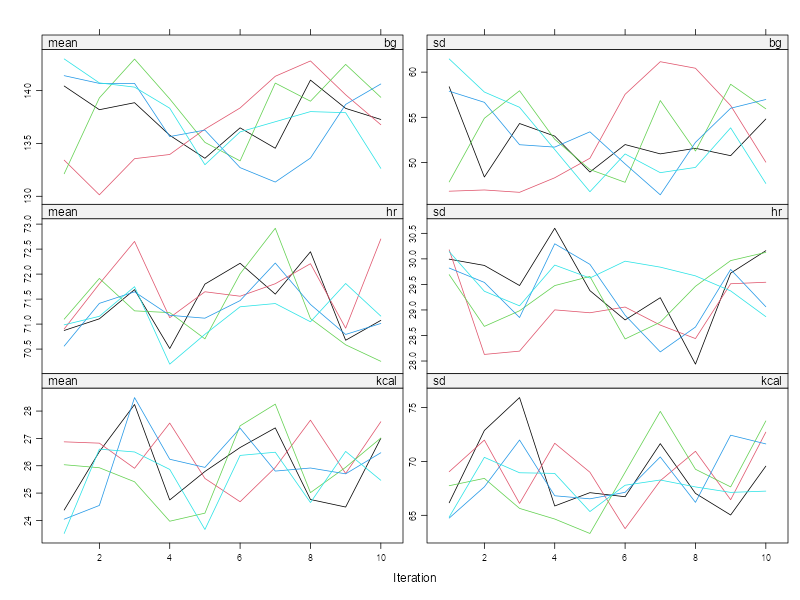


Extracting imputed datasets...
Validation of imputation results:
Remaining missing values after imputation:
# A tibble: 6 x 2
  variable  missing_count
  <chr>             <int>
1 timestamp             0
2 uuid                  0
3 bg                    0
4 hr                    0
5 kcal                  0
6 steps                 0

Comparing distributions before/after imputation for key variables:

bg:
Before imputation:
  Mean: 133.648, SD: 47.886, Missing: 100291
After imputation:
  Mean: 134.315, SD: 49.255, Missing: 0

hr:
Before imputation:
  Mean: 63.677, SD: 31.965, Missing: 4092
After imputation:
  Mean: 63.733, SD: 31.958, Missing: 0

steps:
Before imputation:
  Mean: 12.777, SD: 27.738, Missing: 1395
After imputation:
  Mean: 12.775, SD: 27.735, Missing: 0

kcal:
Before imputation:
  Mean: 34.000, SD: 91.275, Missing: 63532
After imputation:
  Mean: 33.184, SD: 89.042, Missing: 0

Updating df_full with imputed data...
MICE imputation process completed successfully!
Final da

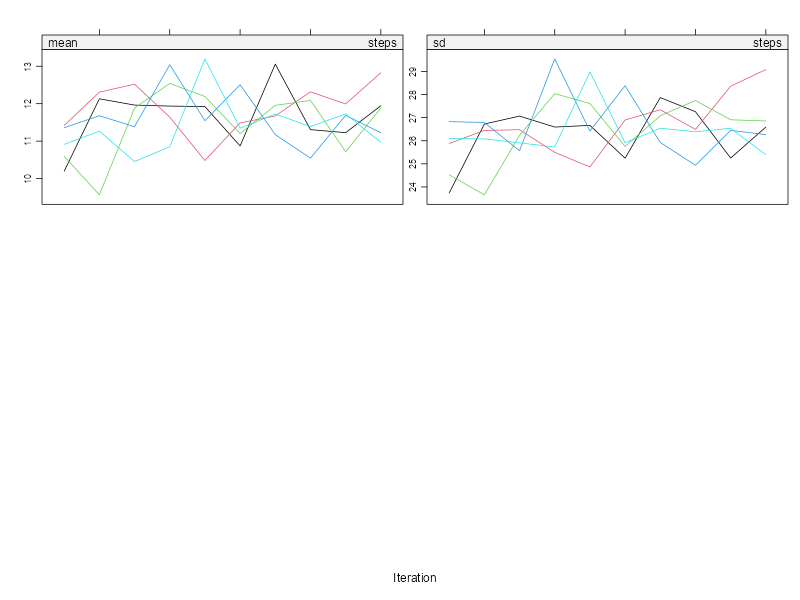

In [9]:
# Load required libraries
# Summary of missing values
missing_summary <- df_full %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "missing_count") %>%
  mutate(missing_percent = missing_count / nrow(df_full) * 100) %>%
  arrange(desc(missing_percent))

print(missing_summary)

# Visualize missing data patterns (optional, comment out if dataset is very large)
if(nrow(df_full) <= 10000) {  # Only create plots for smaller datasets
  cat("\nCreating missing data pattern visualization...\n")

  # Missing data pattern plot
  missing_pattern_plot <- VIM::aggr(df_full,
                                   col = c('navyblue', 'red'),
                                   numbers = TRUE,
                                   sortVars = TRUE,
                                   plot = FALSE)

  # Display the plot
  plot(missing_pattern_plot)
} else {
  cat("Dataset too large for missing pattern visualization (>10,000 rows)\n")
}

# Prepare data for MICE imputation
cat("\nPreparing data for MICE imputation...\n")

# Check for variables with too many missing values (>50%) that might cause issues
high_missing_vars <- missing_summary %>%
  filter(missing_percent > 50) %>%
  pull(variable)

if(length(high_missing_vars) > 0) {
  cat("Warning: Variables with >50% missing values:\n")
  cat(paste(high_missing_vars, collapse = ", "), "\n")
  cat("Consider excluding these from imputation or handling separately.\n")
}

# Set up MICE parameters
# You can adjust these parameters based on your data characteristics
mice_params <- list(
  m = 5,           # Number of multiple imputations
  method = 'auto', # Let MICE choose appropriate methods automatically
  printFlag = TRUE, # Print progress
  seed = 123       # For reproducibility
)

# Perform initial MICE setup to check methods and predictor matrix
cat("\nSetting up MICE configuration...\n")

# Initialize MICE to see default settings
init_mice <- mice(df_full, maxit = 0, printFlag = FALSE)

# Display the imputation methods that will be used
cat("Imputation methods for each variable:\n")
print(init_mice$method)

# Display predictor matrix (which variables predict which)
cat("\nPredictor matrix structure:\n")
cat("(Showing first few rows/columns only)\n")
if(ncol(df_full) <= 10) {
  print(init_mice$predictorMatrix)
} else {
  print(init_mice$predictorMatrix[1:min(5, nrow(init_mice$predictorMatrix)),
                                  1:min(10, ncol(init_mice$predictorMatrix))])
  cat("... (truncated for display)\n")
}

# Custom method specification (optional)
# You might want to specify methods for certain variables
custom_methods <- init_mice$method

# Example customizations (uncomment and modify as needed):
# custom_methods["bg"] <- "pmm"        # Predictive mean matching for bg
# custom_methods["hr"] <- "pmm"        # Predictive mean matching for hr
# custom_methods["steps"] <- "pmm"     # Predictive mean matching for steps
# custom_methods["kcal"] <- "pmm"      # Predictive mean matching for kcal

# Custom predictor matrix (optional)
# You might want to exclude certain variables from predicting others
predictor_matrix <- init_mice$predictorMatrix

# Example: Don't use timestamp to predict other variables (uncomment if needed)
if("timestamp" %in% colnames(df_full)) {
  predictor_matrix[, "timestamp"] <- 0
}

# Example: Don't predict uuid (it shouldn't be imputed anyway)
if("uuid" %in% colnames(df_full)) {
  predictor_matrix["uuid", ] <- 0
  custom_methods["uuid"] <- ""  # Don't impute uuid
}

# Perform MICE imputation
cat("\nStarting MICE imputation...\n")
cat("This may take several minutes depending on dataset size...\n")
df_full_preimputation <- df_full
start_time <- Sys.time()

# Run MICE with custom settings
mice_result <- mice(df_full,
                   m = mice_params$m,
                   method = custom_methods,
                   predictorMatrix = predictor_matrix,
                   maxit = 10,  # Number of iterations
                   seed = mice_params$seed,
                   printFlag = mice_params$printFlag)

end_time <- Sys.time()
cat(sprintf("\nMICE imputation completed in %.2f minutes\n",
           as.numeric(difftime(end_time, start_time, units = "mins"))))

# Check convergence
cat("\nChecking convergence...\n")
plot(mice_result, layout = c(2, 3))  # Convergence plots

# Get imputed datasets
cat("\nExtracting imputed datasets...\n")

# Complete the data with the first imputation
df_full_imputed_1 <- complete(mice_result, 1)

# Pool all imputations (for analysis, use this approach)
# For now, we'll use the first completed dataset
df_full_imputed <- df_full_imputed_1

# Alternative: Create a pooled dataset using the mean of imputations for continuous variables
# This is less theoretically sound but sometimes used for convenience
if(FALSE) {  # Set to TRUE if you want to create a pooled dataset
  cat("Creating pooled dataset (averaging across imputations)...\n")

  # Get all completed datasets
  completed_datasets <- map(1:mice_params$m, ~ complete(mice_result, .x))

  # Pool continuous variables by averaging
  df_full_pooled <- df_full
  continuous_vars <- sapply(df_full, is.numeric)

  for(var in names(df_full)[continuous_vars]) {
    if(any(is.na(df_full[[var]]))) {
      # Average across all imputations for this variable
      pooled_values <- map_dfc(completed_datasets, ~ .x[[var]]) %>%
        rowMeans(na.rm = TRUE)

      # Replace missing values with pooled values
      missing_idx <- is.na(df_full[[var]])
      df_full_pooled[[var]][missing_idx] <- pooled_values[missing_idx]
    }
  }

  df_full_imputed <- df_full_pooled
}

# Validate imputation results
cat("Validation of imputation results:\n")
# Check for remaining missing values
remaining_missing <- df_full_imputed %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "missing_count")

cat("Remaining missing values after imputation:\n")
print(remaining_missing)

# Compare distributions before and after imputation (for key variables)
key_vars <- c("bg", "hr", "steps", "kcal")
existing_key_vars <- intersect(key_vars, names(df_full))

if(length(existing_key_vars) > 0) {
  cat("\nComparing distributions before/after imputation for key variables:\n")

  for(var in existing_key_vars) {
    cat(sprintf("\n%s:\n", var))
    cat("Before imputation:\n")
    cat(sprintf("  Mean: %.3f, SD: %.3f, Missing: %d\n",
               mean(df_full[[var]], na.rm = TRUE),
               sd(df_full[[var]], na.rm = TRUE),
               sum(is.na(df_full[[var]]))))

    cat("After imputation:\n")
    cat(sprintf("  Mean: %.3f, SD: %.3f, Missing: %d\n",
               mean(df_full_imputed[[var]], na.rm = TRUE),
               sd(df_full_imputed[[var]], na.rm = TRUE),
               sum(is.na(df_full_imputed[[var]]))))
  }
}

# Update df_full with imputed data
cat("\nUpdating df_full with imputed data...\n")


cat("MICE imputation process completed successfully!\n")
cat(sprintf("Final dataset shape: %d rows x %d columns\n", nrow(df_full_imputed), ncol(df_full_imputed)))

# Optional: Save the MICE object for later analysis
# saveRDS(mice_result, "mice_imputation_result.rds")
# cat("MICE result object saved as 'mice_imputation_result.rds'\n")

# Note: For proper multiple imputation analysis, you should:
# 1. Fit your model on each of the m imputed datasets
# 2. Pool the results using Rubin's rules
# 3. Use functions like pool() from the mice package
#
# Example for pooled analysis:
# # Fit model on each imputed dataset
# models <- with(mice_result, lm(outcome ~ predictor1 + predictor2))
# # Pool results
# pooled_results <- pool(models)
# summary(pooled_results)


Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor

Creating imputation visualizations...


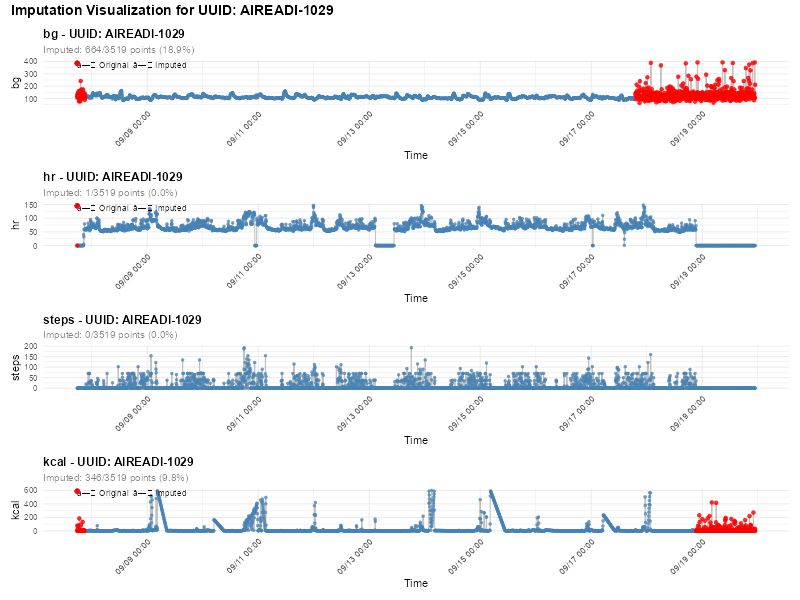

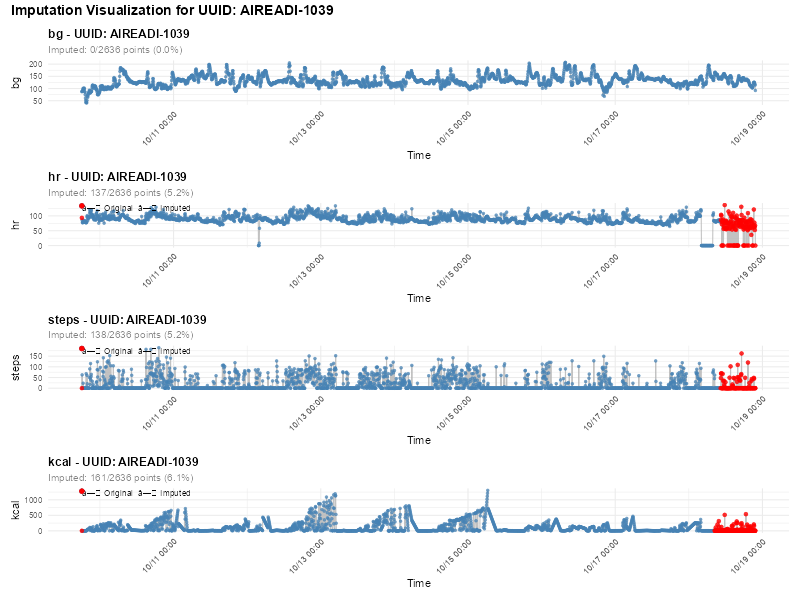

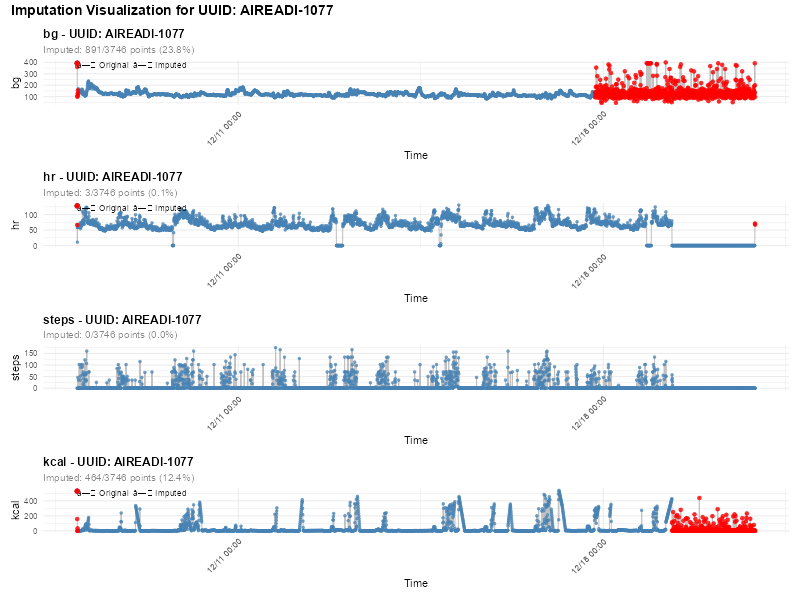

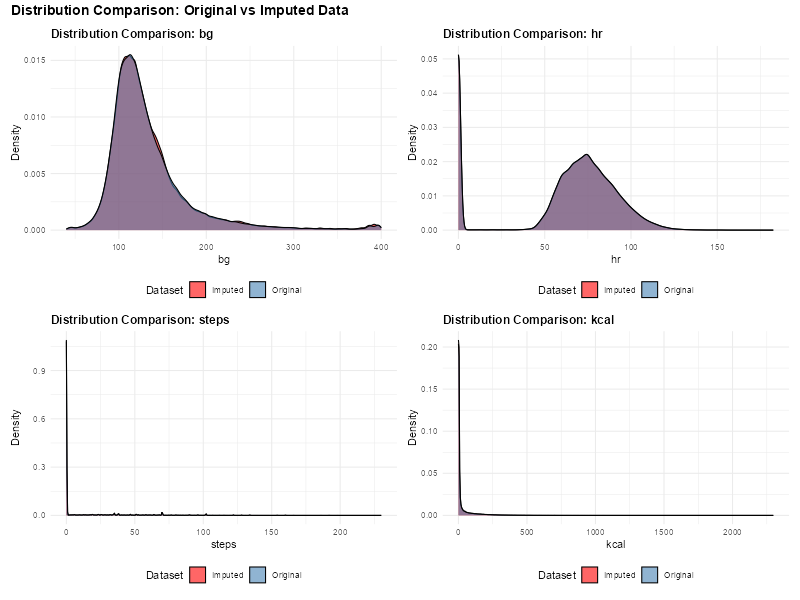

In [10]:
# Load required libraries
library(scales)

# Function to create imputation visualization for a specific UUID and variable
plot_imputation_for_uuid <- function(original_data, imputed_data, target_uuid,
                                    variables = c("bg", "hr", "steps", "kcal", "ox_sat_percent"),
                                    timestamp_col = "timestamp") {

  # Filter data for the specific UUID
  original_uuid <- original_data %>% filter(uuid == target_uuid)
  imputed_uuid <- imputed_data %>% filter(uuid == target_uuid)

  if(nrow(original_uuid) == 0) {
    cat(sprintf("No data found for UUID: %s\n", target_uuid))
    return(NULL)
  }

  # Check which variables exist in the data
  existing_vars <- intersect(variables, names(original_uuid))

  if(length(existing_vars) == 0) {
    cat(sprintf("None of the specified variables found for UUID: %s\n", target_uuid))
    return(NULL)
  }

  # Create plots for each variable
  plots <- map(existing_vars, function(var) {

    # Combine original and imputed data with indicators
    combined_data <- original_uuid %>%
      select(all_of(c("uuid", timestamp_col, var))) %>%
      mutate(
        original_value = .data[[var]],
        imputed_value = imputed_uuid[[var]],
        was_missing = is.na(original_value),
        data_type = case_when(
          is.na(original_value) ~ "Imputed",
          TRUE ~ "Original"
        )
      ) %>%
      # Create final value column (original where available, imputed where missing)
      mutate(final_value = ifelse(is.na(original_value), imputed_value, original_value))

    # Count imputed values
    n_imputed <- sum(combined_data$was_missing)
    n_total <- nrow(combined_data)
    pct_imputed <- round(n_imputed / n_total * 100, 1)

    # Create the plot
    p <- ggplot(combined_data, aes(x = .data[[timestamp_col]])) +
      # Plot all values as a continuous line
      geom_line(aes(y = final_value), color = "gray70", size = 0.5, alpha = 0.8) +
      # Highlight original values
      geom_point(data = filter(combined_data, data_type == "Original"),
                aes(y = final_value), color = "steelblue", size = 1, alpha = 0.7) +
      # Highlight imputed values
      geom_point(data = filter(combined_data, data_type == "Imputed"),
                aes(y = final_value), color = "red", size = 1.5, alpha = 0.8) +
      labs(
        title = sprintf("%s - UUID: %s", var, target_uuid),
        subtitle = sprintf("Imputed: %d/%d points (%.1f%%)", n_imputed, n_total, pct_imputed),
        x = "Time",
        y = var
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 12, face = "bold"),
        plot.subtitle = element_text(size = 10, color = "gray50"),
        axis.text.x = element_text(angle = 45, hjust = 1)
      ) +
      scale_x_datetime(labels = date_format("%m/%d %H:%M"))

    # Add legend if there are imputed values
    if(n_imputed > 0) {
      p <- p +
        annotate("text", x = min(combined_data[[timestamp_col]]),
                y = max(combined_data$final_value, na.rm = TRUE),
                label = "● Original  ● Imputed",
                hjust = 0, vjust = 1, size = 3,
                color = "black") +
        annotate("point", x = min(combined_data[[timestamp_col]]) +
                 as.numeric(diff(range(combined_data[[timestamp_col]]))) * 0.02,
                y = max(combined_data$final_value, na.rm = TRUE) -
                 diff(range(combined_data$final_value, na.rm = TRUE)) * 0.02,
                color = "steelblue", size = 2) +
        annotate("point", x = min(combined_data[[timestamp_col]]) +
                 as.numeric(diff(range(combined_data[[timestamp_col]]))) * 0.1,
                y = max(combined_data$final_value, na.rm = TRUE) -
                 diff(range(combined_data$final_value, na.rm = TRUE)) * 0.02,
                color = "red", size = 2)
    }

    return(p)
  })

  # Combine plots using patchwork
  if(length(plots) == 1) {
    return(plots[[1]])
  } else {
    combined_plot <- wrap_plots(plots, ncol = 1) +
      plot_annotation(
        title = sprintf("Imputation Visualization for UUID: %s", target_uuid),
        theme = theme(plot.title = element_text(size = 14, face = "bold"))
      )
    return(combined_plot)
  }
}

# Function to create summary visualization across multiple UUIDs
plot_imputation_summary <- function(original_data, imputed_data,
                                   variables = c("bg", "hr", "steps", "kcal", "ox_sat_percent"),
                                   n_uuids = 6, timestamp_col = "timestamp") {

  # Calculate missingness by UUID for each variable
  missingness_by_uuid <- original_data %>%
    group_by(uuid) %>%
    summarise(across(all_of(intersect(variables, names(original_data))),
                    ~ sum(is.na(.)) / length(.) * 100),
             .groups = "drop")

  # Select UUIDs with varying levels of missingness for visualization
  selected_uuids <- missingness_by_uuid %>%
    # Calculate total missingness across all variables
    rowwise() %>%
    mutate(total_missing = mean(c_across(-uuid), na.rm = TRUE)) %>%
    ungroup() %>%
    # Select UUIDs with different missingness levels
    arrange(total_missing) %>%
    slice(c(1, n() %/% 4, n() %/% 2, 3 * n() %/% 4, n() - 1, n())) %>%
    slice_head(n = n_uuids) %>%
    pull(uuid)

  cat("Creating imputation summary for selected UUIDs:\n")
  cat(paste(selected_uuids, collapse = ", "), "\n")

  # Create plots for selected UUIDs
  plots <- map(selected_uuids, function(uuid) {
    plot_imputation_for_uuid(original_data, imputed_data, uuid, variables, timestamp_col)
  })

  # Remove any NULL plots
  plots <- compact(plots)

  if(length(plots) > 0) {
    return(plots)
  } else {
    cat("No valid plots could be created.\n")
    return(NULL)
  }
}

# Function to create before/after distribution comparison
plot_distribution_comparison <- function(original_data, imputed_data,
                                       variables = c("bg", "hr", "steps", "kcal", "ox_sat_percent")) {

  existing_vars <- intersect(variables, names(original_data))

  if(length(existing_vars) == 0) {
    cat("No specified variables found in the data.\n")
    return(NULL)
  }

  # Create comparison data
  comparison_plots <- map(existing_vars, function(var) {

    # Prepare data for comparison
    comparison_data <- data.frame(
      Original = original_data[[var]],
      Imputed = imputed_data[[var]]
    ) %>%
      pivot_longer(everything(), names_to = "Dataset", values_to = "Value") %>%
      filter(!is.na(Value))

    # Create density plot
    p <- ggplot(comparison_data, aes(x = Value, fill = Dataset)) +
      geom_density(alpha = 0.6) +
      scale_fill_manual(values = c("Original" = "steelblue", "Imputed" = "red")) +
      labs(
        title = sprintf("Distribution Comparison: %s", var),
        x = var,
        y = "Density"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 12, face = "bold"),
        legend.position = "bottom"
      )

    return(p)
  })

  # Combine plots
  if(length(comparison_plots) > 1) {
    combined_plot <- wrap_plots(comparison_plots, ncol = 2) +
      plot_annotation(
        title = "Distribution Comparison: Original vs Imputed Data",
        theme = theme(plot.title = element_text(size = 14, face = "bold"))
      )
    return(combined_plot)
  } else {
    return(comparison_plots[[1]])
  }
}

# Function to create missing data pattern visualization
plot_missing_patterns <- function(original_data, imputed_data,
                                 variables = c("bg", "hr", "steps", "kcal", "ox_sat_percent")) {

  existing_vars <- intersect(variables, names(original_data))

  # Calculate missing patterns
  missing_patterns <- original_data %>%
    select(uuid, all_of(existing_vars)) %>%
    group_by(uuid) %>%
    summarise(across(all_of(existing_vars), ~ sum(is.na(.)) / length(.) * 100),
             .groups = "drop") %>%
    pivot_longer(-uuid, names_to = "Variable", values_to = "Missing_Percent")

  # Create heatmap
  p <- ggplot(missing_patterns, aes(x = Variable, y = reorder(uuid, Missing_Percent),
                                   fill = Missing_Percent)) +
    geom_tile() +
    scale_fill_gradient(low = "white", high = "red", name = "% Missing") +
    labs(
      title = "Missing Data Patterns by UUID and Variable",
      x = "Variable",
      y = "UUID (ordered by missingness)"
    ) +
    theme_minimal() +
    theme(
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      plot.title = element_text(size = 14, face = "bold"),
      axis.text.x = element_text(angle = 45, hjust = 1)
    )

  return(p)
}
# 1. Visualize specific UUIDs
cat("Creating imputation visualizations...\n")

# Get some example UUIDs
example_uuids <- unique(df_full$uuid)[1:3]  # First 3 UUIDs

# Create individual plots
for(uuid in example_uuids) {
   plot <- plot_imputation_for_uuid(df_full_preimputation, df_full_imputed, uuid)
   if(!is.null(plot)) {
     print(plot)
   }
}

# 3. Distribution comparison
dist_plot <- plot_distribution_comparison(df_full_preimputation, df_full_imputed)
if(!is.null(dist_plot)) {
   print(dist_plot)
 }



# Feature engineering

In [11]:
#' Create Time Series Features
#'
#' Generates lag, rolling window, and temporal features for time series data
#'
#' @param data A data frame with 'uuid', 'timestamp', and numeric variables
#' @param variables Character vector of variable names to create features for
#' @param lag_periods Integer vector of lag periods to create
#' @param window_sizes Integer vector of rolling window sizes
#' @return Data frame with original data plus engineered features
create_time_features <- function(data, variables,
                                lag_periods = c(1, 2, 3, 4, 5, 12),
                                window_sizes = c(3, 6, 12)) {

  # Validate inputs
  stopifnot(all(c("uuid", "timestamp") %in% names(data)))
  stopifnot(is.character(variables))
  stopifnot(all(variables %in% names(data)))

  message("Creating time-based and lag features...")

  # Create temporal features first
  result <- data %>%
    mutate(timestamp = as.POSIXct(timestamp)) %>%
    arrange(uuid, timestamp) %>%
    mutate(
      # Temporal features
      hour = hour(timestamp),
      day_of_week = wday(timestamp, week_start = 1) - 1L,
      is_weekend = day_of_week >= 5L,

      # Cyclical encodings
      hour_sin = sin(2 * pi * hour / 24),
      hour_cos = cos(2 * pi * hour / 24),
      day_sin = sin(2 * pi * day_of_week / 7),
      day_cos = cos(2 * pi * day_of_week / 7)
    ) %>%
    group_by(uuid) %>%
    arrange(timestamp, .by_group = TRUE)

  # Create lag features using simple approach
  for (var in variables) {
    for (lag_p in lag_periods) {
      new_col <- paste0(var, "_lag", lag_p)
      result <- result %>%
        mutate(!!new_col := lag(!!sym(var), n = lag_p))
    }
  }

  # Create rolling window features
  for (var in variables) {
    print(var)
    for (w in window_sizes) {
      # Rolling mean
      mean_col <- paste0(var, "_rolling_mean", w)
      result <- result %>%
        mutate(!!mean_col := rollmean(!!sym(var), k = w, fill = NA, align = "right"))

      # Rolling standard deviation
      sd_col <- paste0(var, "_rolling_sd", w)
      result <- result %>%
        mutate(!!sd_col := rollapply(!!sym(var), width = w, FUN = sd, fill = NA, align = "right"))

      # Difference from rolling mean
      diff_col <- paste0(var, "_diff_rolling_mean", w)
      result <- result %>%
        mutate(!!diff_col := !!sym(var) - rollmean(!!sym(var), k = w, fill = NA, align = "right"))
    }
  }
  print(head(result))
  result %>% ungroup()
}

#' Estimate Data Collection Interval
#'
#' Finds the most common time interval between observations (kept for compatibility)
#'
#' @param data Data frame with timestamp column
#' @return Numeric value representing interval in minutes (always returns 5)
estimate_interval <- function(data) {
  # Always return 5 minutes since interval is fixed
  return(5)
}

# Main feature engineering pipeline
create_all_features <- function(data, variables = c("bg", "hr", "kcal", "steps")) {

  # Check which variables actually exist
  available_vars <- intersect(variables, names(data))

  if (length(available_vars) == 0) {
    warning("No specified variables found in data")
    return(data)
  }

  if (length(available_vars) < length(variables)) {
    missing_vars <- setdiff(variables, available_vars)
    message("Variables not found: ", paste(missing_vars, collapse = ", "))
  }

  message("Processing variables: ", paste(available_vars, collapse = ", "))

  # Fixed 5-minute data collection interval
  interval_min <- 5
  message(sprintf("Using fixed collection interval: %d minutes", interval_min))

  # Define exact time-based periods (in minutes) and convert to data periods
  lag_times <- c(5, 10, 15, 20, 25, 60)      # minutes
  window_times <- c(15, 30, 45, 60)          # minutes

  # Convert to periods (number of data points)
  lag_periods <- lag_times / interval_min     # 1, 2, 3, 4, 5, 12 periods
  window_sizes <- window_times / interval_min # 3, 6, 9, 12 periods

  message("Lag periods (data points): ", paste(lag_periods, collapse = ", "))
  message("Window sizes (data points): ", paste(window_sizes, collapse = ", "))
  message("Lag times (minutes): ", paste(lag_times, collapse = ", "))
  message("Window times (minutes): ", paste(window_times, collapse = ", "))

  # Create features
  result <- create_time_features(data, available_vars, lag_periods, window_sizes)

  # Report results
  new_features <- setdiff(names(result), names(data))
  message(sprintf("Added %d new features", length(new_features)))

  if (length(new_features) <= 20) {
    message("New features: ", paste(sort(new_features), collapse = ", "))
  } else {
    sample_features <- sample(new_features, 10)
    message("Sample of new features: ", paste(sort(sample_features), collapse = ", "), " ...")
  }

  result
}

# Apply feature engineering
message("Starting feature engineering on df_full_imputed...")

# Create all features
df_full_featured <- create_all_features(df_full_imputed)

# Update the main dataframe
#df_full_imputed <- df_full_featured

# Summary report
message("FEATURE ENGINEERING COMPLETE")
message(sprintf("Dataset dimensions: %d rows × %d columns",
                nrow(df_full_featured), ncol(df_full_featured)))

# Categorize features
all_cols <- names(df_full_featured)
temporal_features <- grep("^(hour|day_|is_weekend)", all_cols, value = TRUE)
cyclical_features <- grep("_(sin|cos)$", all_cols, value = TRUE)
lag_features <- grep("_lag\\d+$", all_cols, value = TRUE)
rolling_features <- grep("_(mean|sd|diff_mean)\\d+$", all_cols, value = TRUE)

# Display sample
print(head(df_full_featured))

# The lag and rolling operations leave some NA values, let's trim those off
df_full_featured <- drop_na(df_full_featured, matches('bg|hr|steps|kcal'))





Starting feature engineering on df_full_imputed...
Processing variables: bg, hr, kcal, steps
Using fixed collection interval: 5 minutes
Lag periods (data points): 1, 2, 3, 4, 5, 12
Window sizes (data points): 3, 6, 9, 12
Lag times (minutes): 5, 10, 15, 20, 25, 60
Window times (minutes): 15, 30, 45, 60
Creating time-based and lag features...
[1] "bg"
[1] "hr"
[1] "kcal"
[1] "steps"
# A tibble: 6 x 85
# Groups:   uuid [1]
  timestamp           uuid          bg    hr   kcal steps  hour day_of_week is_weekend hour_sin  hour_cos day_sin day_cos
  <dttm>              <chr>      <dbl> <dbl>  <dbl> <dbl> <int>       <dbl> <lgl>         <dbl>     <dbl>   <dbl>   <dbl>
1 2023-09-07 17:43:14 AIREADI-1~  122.     0  1         0    17           3 FALSE        -0.966 -2.59e- 1   0.434  -0.901
2 2023-09-07 17:48:14 AIREADI-1~  107.     0 77.3       0    17           3 FALSE        -0.966 -2.59e- 1   0.434  -0.901
3 2023-09-07 17:53:14 AIREADI-1~  138.     0  2.58      0    17           3 FALSE       

In [12]:
# Clean up the workspace
rm(df_full_imputed_1)
rm(df_full_imputed)
rm(df_full)
rm(df_full_preimputation)
rm(df_full_cleaned)

# Feature selection


Starting multi-horizon XGBoost forecasting pipeline...
Preparing data for 5 prediction horizons: 15, 30, 45, 60, 120 minutes
Corresponding to 3, 6, 9, 12, 24 periods ahead
Creating future targets for each prediction horizon...
Creating bg_15min (lead by 3 periods)
Creating bg_30min (lead by 6 periods)
Creating bg_45min (lead by 9 periods)
Creating bg_60min (lead by 12 periods)
Creating bg_120min (lead by 24 periods)
Created future targets: bg_15min, bg_30min, bg_45min, bg_60min, bg_120min
Using 86 features for prediction
Horizon 15 min: 541953 valid observations
Horizon 30 min: 541482 valid observations
Horizon 45 min: 541011 valid observations
Horizon 60 min: 540540 valid observations
Horizon 120 min: 538656 valid observations
Fitting XGBoost models for multiple horizons...
Training model for 15 minute horizon (433499 train, 108454 test observations)...
Training model for 30 minute horizon (433124 train, 108358 test observations)...
Training model for 45 minute horizon (432747 train, 

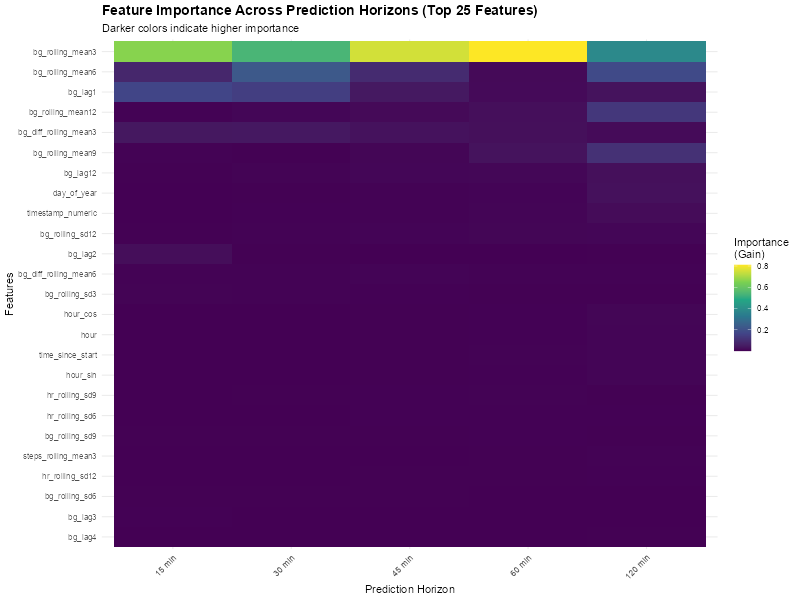

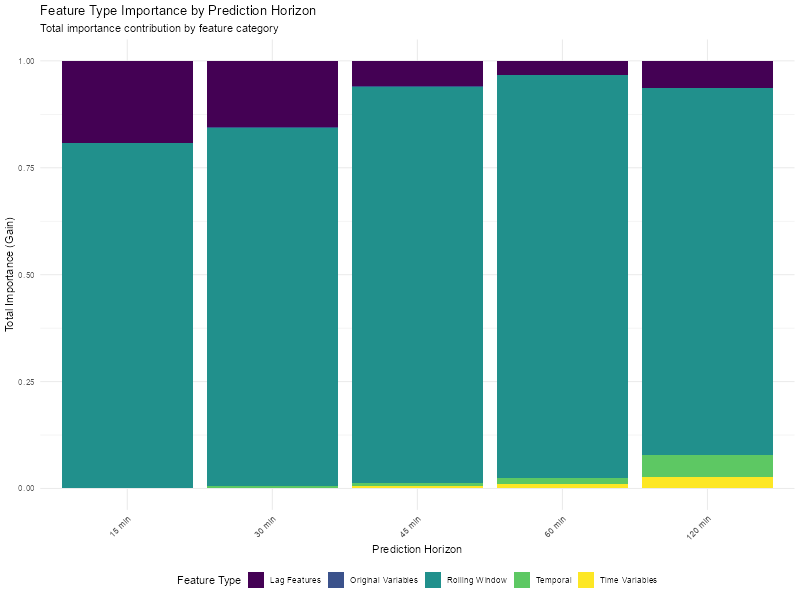


Results saved in objects:
- multi_horizon_models: Fitted models for each horizon
- importance_analysis: Feature importance analysis across horizons
- performance_analysis: Performance metrics across horizons
- horizon_data: Processed data for each horizon

Trained 5 models for prediction horizons: 15, 30, 45, 60, 120 minutes


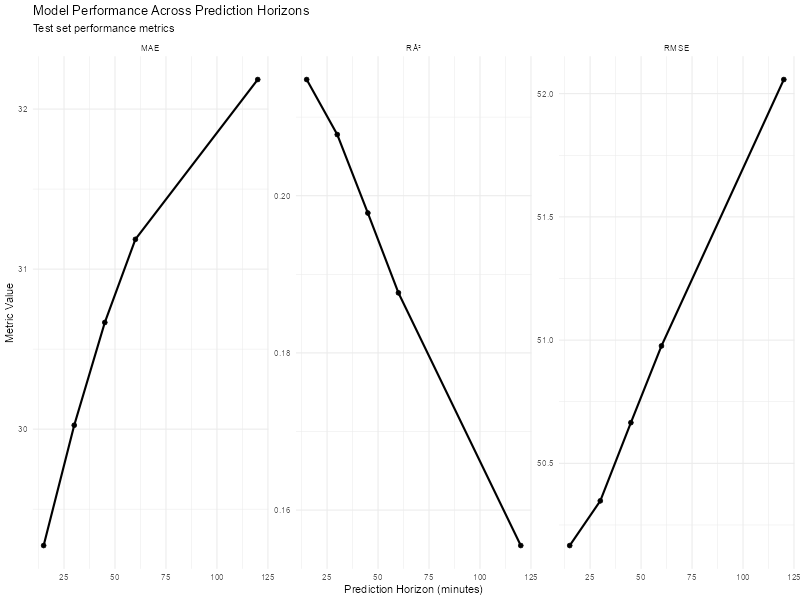

In [13]:

#' Prepare Multi-Horizon Time Series Data for XGBoost
#' 
#' Prepares time series data with multiple future prediction targets
#' 
#' @param data Data frame with timestamp, uuid, and features
#' @param target_var Character name of target variable (default: "bg")
#' @param prediction_horizons Vector of prediction horizons in minutes
#' @param exclude_vars Character vector of variables to exclude from features
#' @return List with train/test splits and feature information for each horizon
prepare_multi_horizon_data <- function(data, target_var = "bg", 
                                      prediction_horizons = c(5, 10, 15, 30, 45, 60, 90, 120),
                                      exclude_vars = c("timestamp", "uuid")) {
  
  # Convert prediction horizons from minutes to periods (5-minute intervals)
  horizon_periods <- prediction_horizons / 5
  
  message(sprintf("Preparing data for %d prediction horizons: %s minutes", 
                 length(prediction_horizons), paste(prediction_horizons, collapse = ", ")))
  message(sprintf("Corresponding to %s periods ahead", paste(horizon_periods, collapse = ", ")))
  
  # Remove rows with missing target variable
  clean_data <- data %>%
    filter(!is.na(!!sym(target_var))) %>%
    arrange(uuid, timestamp)
  
  # Add temporal features if not already present
  if(!"timestamp_numeric" %in% names(clean_data)) {
    clean_data <- clean_data %>%
      mutate(
        timestamp_numeric = as.numeric(timestamp),
        time_since_start = as.numeric(timestamp - min(timestamp, na.rm = TRUE)) / 3600, # hours
        day_of_year = yday(timestamp),
        week_of_year = week(timestamp)
      )
  }
  
  # Create future targets for each horizon within each UUID
  message("Creating future targets for each prediction horizon...")
  
  clean_data <- clean_data %>%
    group_by(uuid) %>%
    arrange(timestamp, .by_group = TRUE)
  
  # Create future targets one by one (more reliable than across with .unpack)
  for(i in seq_along(prediction_horizons)) {
    horizon_min <- prediction_horizons[i]
    horizon_periods_i <- horizon_min / 5  # Convert minutes to 5-minute periods
    target_col_name <- paste0(target_var, "_", horizon_min, "min")
    
    message(sprintf("Creating %s (lead by %d periods)", target_col_name, horizon_periods_i))
    
    clean_data <- clean_data %>%
      mutate(!!target_col_name := lead(!!sym(target_var), n = as.integer(horizon_periods_i)))
  }
  
  clean_data <- clean_data %>% ungroup()
  
  message(sprintf("Created future targets: %s", 
                 paste(paste0(target_var, "_", prediction_horizons, "min"), collapse = ", ")))
  
  # Identify feature columns (exclude target, future targets, and specified variables)
  future_target_cols <- paste0(target_var, "_", prediction_horizons, "min")
  all_exclude <- c(target_var, future_target_cols, exclude_vars)
  feature_cols <- setdiff(names(clean_data), all_exclude)
  
  message(sprintf("Using %d features for prediction", length(feature_cols)))
  
  # Prepare data for each prediction horizon
  horizon_data <- map(prediction_horizons, function(horizon) {
    
    horizon_target_col <- paste0(target_var, "_", horizon, "min")
    
    # Remove rows where future target is NA (can't predict these)
    valid_data <- clean_data %>%
      filter(!is.na(!!sym(horizon_target_col)))
    
    message(sprintf("Horizon %d min: %d valid observations", horizon, nrow(valid_data)))
    
    # Create feature matrix and target vector
    feature_matrix <- valid_data %>%
      select(all_of(feature_cols)) %>%
      # Convert logical columns to numeric
      mutate(across(where(is.logical), as.numeric)) %>%
      as.matrix()
    
    target_vector <- valid_data[[horizon_target_col]]
    
    # Handle any remaining NA values in features
    if(any(is.na(feature_matrix))) {
      for(i in 1:ncol(feature_matrix)) {
        col_data <- feature_matrix[, i]
        if(any(is.na(col_data))) {
          if(is.numeric(col_data)) {
            feature_matrix[is.na(col_data), i] <- median(col_data, na.rm = TRUE)
          } else {
            mode_val <- names(sort(table(col_data), decreasing = TRUE))[1]
            feature_matrix[is.na(col_data), i] <- mode_val
          }
        }
      }
    }
    
    # Time-based split within each UUID (last 20% for testing)
    split_indices <- valid_data %>%
      group_by(uuid) %>%
      arrange(timestamp, .by_group = TRUE) %>%
      mutate(
        row_num = row_number(),
        total_rows = n(),
        split_point = floor(0.8 * total_rows),
        is_train = row_num <= split_point
      ) %>%
      ungroup() %>%
      mutate(global_index = row_number())
    
    train_indices <- split_indices %>% filter(is_train) %>% pull(global_index)
    test_indices <- split_indices %>% filter(!is_train) %>% pull(global_index)
    
    list(
      horizon = horizon,
      X_train = feature_matrix[train_indices, ],
      X_test = feature_matrix[test_indices, ],
      y_train = target_vector[train_indices],
      y_test = target_vector[test_indices],
      feature_names = feature_cols,
      train_data = valid_data[train_indices, ],
      test_data = valid_data[test_indices, ],
      split_indices = split_indices,
      n_train = length(train_indices),
      n_test = length(test_indices)
    )
  }) %>%
    set_names(paste0("horizon_", prediction_horizons, "min"))
  
  return(horizon_data)
}

#' Fit XGBoost Models for Multiple Horizons
#' 
#' Fits separate XGBoost models for each prediction horizon
#' 
#' @param horizon_data List from prepare_multi_horizon_data()
#' @param nrounds Number of boosting rounds
#' @param early_stopping_rounds Early stopping patience
#' @param use_gpu Logical, whether to use GPU acceleration
#' @return List of fitted XGBoost models for each horizon
fit_multi_horizon_models <- function(horizon_data, nrounds = 500, early_stopping_rounds = 50, use_gpu = FALSE) {
  
  message("Fitting XGBoost models for multiple horizons...")
  
  # Check GPU availability if requested (same as before)
  if(use_gpu) {
    tryCatch({
      test_gpu <- xgb.train(
        params = list(tree_method = "gpu_hist", gpu_id = 0),
        data = xgb.DMatrix(matrix(rnorm(100), 10, 10), label = rnorm(10)),
        nrounds = 1,
        verbose = 0
      )
      message("GPU acceleration enabled!")
      gpu_available <- TRUE
    }, error = function(e) {
      message("GPU not available. Using CPU.")
      gpu_available <- FALSE
      use_gpu <<- FALSE
    })
  } else {
    gpu_available <- FALSE
  }
  
  # Set up parameters
  if(use_gpu && gpu_available) {
    params <- list(
      objective = "reg:squarederror",
      eval_metric = "rmse",
      tree_method = "gpu_hist",
      gpu_id = 0,
      max_depth = 6,
      eta = 0.1,
      subsample = 0.8,
      colsample_bytree = 0.8,
      min_child_weight = 3,
      gamma = 0,
      lambda = 1,
      alpha = 0
    )
  } else {
    params <- list(
      objective = "reg:squarederror",
      eval_metric = "rmse",
      tree_method = "hist",
      max_depth = 6,
      eta = 0.1,
      subsample = 0.8,
      colsample_bytree = 0.8,
      min_child_weight = 3,
      gamma = 0,
      lambda = 1,
      alpha = 0,
      nthread = parallel::detectCores() - 2
    )
  }
  
  # Train model for each horizon
  models <- map(horizon_data, function(data) {
    
    message(sprintf("Training model for %d minute horizon (%d train, %d test observations)...", 
                   data$horizon, data$n_train, data$n_test))
    
    # Set column names
    colnames(data$X_train) <- data$feature_names
    colnames(data$X_test) <- data$feature_names
    
    # Create DMatrix objects
    dtrain <- xgb.DMatrix(data = data$X_train, label = data$y_train)
    dtest <- xgb.DMatrix(data = data$X_test, label = data$y_test)
    
    # Train model
    model <- xgb.train(
      params = params,
      data = dtrain,
      nrounds = nrounds,
      watchlist = list(train = dtrain, test = dtest),
      early_stopping_rounds = early_stopping_rounds,
      verbose = 0  # Reduce verbosity for multiple models
    )
    
    # Return model with metadata
    list(
      model = model,
      horizon = data$horizon,
      feature_names = data$feature_names,
      n_train = data$n_train,
      n_test = data$n_test,
      best_iteration = model$best_iteration %||% model$niter
    )
  })
  
  return(models)
}

#' Analyze Multi-Horizon Feature Importance
#' 
#' Extracts and compares feature importance across prediction horizons
#' 
#' @param models List of fitted models from fit_multi_horizon_models()
#' @param top_n Number of top features to show in plots
#' @return List with importance analysis across horizons
analyze_multi_horizon_importance <- function(models, top_n = 20) {
  
  message("Analyzing feature importance across prediction horizons...")
  
  # Extract importance for each model
  importance_list <- map(models, function(model_data) {
    importance <- xgb.importance(
      feature_names = model_data$feature_names,
      model = model_data$model
    ) %>%
      mutate(
        horizon = model_data$horizon,
        rank = row_number(),
        feature_type = case_when(
          grepl("_lag\\d+$", Feature) ~ "Lag Features",
          grepl("_(mean|sd|diff_mean)\\d+$", Feature) ~ "Rolling Window",
          grepl("^(hour|day_|is_weekend)", Feature) ~ "Temporal",
          grepl("_(sin|cos)$", Feature) ~ "Cyclical",
          Feature %in% c("timestamp_numeric", "time_since_start", "day_of_year", "week_of_year") ~ "Time Variables",
          TRUE ~ "Original Variables"
        )
      )
    return(importance)
  })
  
  # Combine all importance data
  combined_importance <- bind_rows(importance_list)
  
  # Create heatmap of top features across horizons
  top_features_overall <- combined_importance %>%
    group_by(Feature) %>%
    summarise(avg_gain = mean(Gain), .groups = "drop") %>%
    slice_max(avg_gain, n = top_n) %>%
    pull(Feature)
  
  heatmap_data <- combined_importance %>%
    filter(Feature %in% top_features_overall) %>%
    select(Feature, horizon, Gain, feature_type) %>%
    mutate(horizon = factor(paste0(horizon, " min"), 
                           levels = paste0(sort(unique(horizon)), " min")))
  
  # Feature importance heatmap
  importance_heatmap <- ggplot(heatmap_data, aes(x = horizon, y = reorder(Feature, Gain), fill = Gain)) +
    geom_tile() +
    scale_fill_viridis_c(name = "Importance\n(Gain)") +
    labs(
      title = sprintf("Feature Importance Across Prediction Horizons (Top %d Features)", top_n),
      subtitle = "Darker colors indicate higher importance",
      x = "Prediction Horizon",
      y = "Features"
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.text.y = element_text(size = 8),
      plot.title = element_text(size = 14, face = "bold")
    )
  
  # Feature type importance by horizon
  type_summary <- combined_importance %>%
    group_by(horizon, feature_type) %>%
    summarise(
      n_features = n(),
      total_importance = sum(Gain),
      avg_importance = mean(Gain),
      .groups = "drop"
    )
  
  type_plot <- ggplot(type_summary, aes(x = factor(paste0(horizon, " min"), 
                                                  levels = paste0(sort(unique(horizon)), " min")), 
                                       y = total_importance, fill = feature_type)) +
    geom_col(position = "stack") +
    scale_fill_viridis_d(name = "Feature Type") +
    labs(
      title = "Feature Type Importance by Prediction Horizon",
      subtitle = "Total importance contribution by feature category",
      x = "Prediction Horizon",
      y = "Total Importance (Gain)"
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.position = "bottom"
    )
  
  # Top features for each horizon
  top_by_horizon <- combined_importance %>%
    group_by(horizon) %>%
    slice_max(Gain, n = 10) %>%
    select(horizon, Feature, Gain, feature_type, rank)
  
  # Feature stability analysis (how consistent is importance across horizons)
  feature_stability <- combined_importance %>%
    group_by(Feature) %>%
    summarise(
      n_horizons = n(),
      avg_gain = mean(Gain),
      sd_gain = sd(Gain),
      cv_gain = sd_gain / avg_gain,  # Coefficient of variation
      min_rank = min(rank),
      max_rank = max(rank),
      rank_range = max_rank - min_rank,
      .groups = "drop"
    ) %>%
    arrange(desc(avg_gain))
  
  return(list(
    combined_importance = combined_importance,
    importance_heatmap = importance_heatmap,
    type_plot = type_plot,
    type_summary = type_summary,
    top_by_horizon = top_by_horizon,
    feature_stability = feature_stability,
    top_features_overall = top_features_overall
  ))
}

#' Evaluate Multi-Horizon Model Performance
#' 
#' Evaluates performance metrics for all prediction horizons
#' 
#' @param models List of fitted models
#' @param horizon_data Original horizon data
#' @return Performance analysis across horizons
evaluate_multi_horizon_performance <- function(models, horizon_data) {
  
  message("Evaluating multi-horizon model performance...")
  
  # Calculate performance for each horizon
  performance_list <- map2(models, horizon_data, function(model_data, data) {
    
    # Make predictions
    train_pred <- predict(model_data$model, data$X_train)
    test_pred <- predict(model_data$model, data$X_test)
    
    # Calculate metrics
    train_rmse <- sqrt(mean((data$y_train - train_pred)^2))
    test_rmse <- sqrt(mean((data$y_test - test_pred)^2))
    train_mae <- mean(abs(data$y_train - train_pred))
    test_mae <- mean(abs(data$y_test - test_pred))
    train_r2 <- cor(data$y_train, train_pred)^2
    test_r2 <- cor(data$y_test, test_pred)^2
    
    data.frame(
      horizon = data$horizon,
      train_rmse = train_rmse,
      test_rmse = test_rmse,
      train_mae = train_mae,
      test_mae = test_mae,
      train_r2 = train_r2,
      test_r2 = test_r2,
      best_iteration = model_data$best_iteration
    )
  })
  
  # Combine performance metrics
  performance_df <- bind_rows(performance_list)
  
  # Create performance plots
  perf_long <- performance_df %>%
    select(horizon, test_rmse, test_mae, test_r2) %>%
    pivot_longer(-horizon, names_to = "metric", values_to = "value") %>%
    mutate(
      metric_label = case_when(
        metric == "test_rmse" ~ "RMSE",
        metric == "test_mae" ~ "MAE", 
        metric == "test_r2" ~ "R²"
      )
    )
  
  performance_plot <- ggplot(perf_long, aes(x = horizon, y = value)) +
    geom_line(size = 1) +
    geom_point(size = 2) +
    facet_wrap(~metric_label, scales = "free_y") +
    labs(
      title = "Model Performance Across Prediction Horizons",
      subtitle = "Test set performance metrics",
      x = "Prediction Horizon (minutes)",
      y = "Metric Value"
    ) +
    theme_minimal()
  
  return(list(
    performance_df = performance_df,
    performance_plot = performance_plot
  ))
}

# Main execution pipeline for multi-horizon forecasting
message("Starting multi-horizon XGBoost forecasting pipeline...")

# Define prediction horizons (in minutes)
prediction_horizons <- c(15, 30, 45, 60, 120)

# Prepare multi-horizon data
horizon_data <- prepare_multi_horizon_data(
  df_full_featured, 
  target_var = "bg",
  prediction_horizons = prediction_horizons
)

# Fit models for each horizon
multi_horizon_models <- fit_multi_horizon_models(
  horizon_data, 
  nrounds = 500,
  early_stopping_rounds = 30,
  use_gpu = FALSE
)

# Analyze feature importance across horizons
importance_analysis <- analyze_multi_horizon_importance(
  multi_horizon_models,
  top_n = 25
)

# Evaluate performance across horizons
performance_analysis <- evaluate_multi_horizon_performance(
  multi_horizon_models,
  horizon_data
)

# Display results
message("\n", paste(rep("=", 70), collapse = ""))
message("MULTI-HORIZON MODEL TRAINING COMPLETE")
message(paste(rep("=", 70), collapse = ""))

# Print performance summary
message("\nPerformance Summary Across Horizons:")
print(performance_analysis$performance_df)

# Print feature importance summary
message("\nFeature Type Importance Summary:")
print(importance_analysis$type_summary)

# Print most stable features across horizons
message("\nMost Stable Important Features (Top 10):")
stable_features <- importance_analysis$feature_stability %>%
  filter(n_horizons == length(prediction_horizons)) %>%  # Present in all horizons
  arrange(cv_gain) %>%  # Most stable (low coefficient of variation)
  head(10)
print(stable_features %>% select(Feature, avg_gain, cv_gain, rank_range))

# Display plots
message("\nGenerating plots...")
print(importance_analysis$importance_heatmap)
print(importance_analysis$type_plot)
print(performance_analysis$performance_plot)

# Save results
message("\nResults saved in objects:")
message("- multi_horizon_models: Fitted models for each horizon")
message("- importance_analysis: Feature importance analysis across horizons")
message("- performance_analysis: Performance metrics across horizons")
message("- horizon_data: Processed data for each horizon")

message(sprintf("\nTrained %d models for prediction horizons: %s minutes", 
               length(prediction_horizons), paste(prediction_horizons, collapse = ", ")))